# Garbage Net:一种基于手工特征与传统机器学习方法的垃圾图像分类模型

## 摘要

本项目研究 10 类垃圾图像分类任务，类别包括 battery、biological、cardboard、clothes、glass、metal、paper、plastic、shoes 和 trash。任务难点主要体现在三个方面：第一，图像并非简单的白底单物体场景，背景、光照、主体尺寸和拍摄角度存在较大变化；第二，类别分布不均衡，trash 仅有 453 张，而 clothes 达到 1892 张；第三，部分类别存在真实视觉边界模糊，例如 plastic 与 glass 都可能透明或反光，paper、cardboard 与 plastic 包装也可能在颜色和形状上接近。

为了贯彻本学期机器学习课程的内容，本项目没有采用端到端神经网络训练，而是构建了一条完整的传统机器学习建模路线：首先对数据集进行质量审查与固定分层划分，然后从图像中提取 F0-F6 七组特征，包括原始像素基线、颜色特征、纹理特征、HOG 梯度方向特征、形状特征、GIST 全局结构特征以及 SIFT/ORB Bag-of-Features 局部词袋特征；随后通过固定参数单特征基线、单特征候选调参、特征融合广筛、强模型精调、LightGBM 消融、类别不平衡处理和 stacking 集成逐步筛选最终方案。整个实验过程使用 validation 集进行模型选择和参数决策，test 集在最终模型封存后只使用一次。

本研究最终选出最优 stacking 集成模型，即 **Garbage Net**。Garbage Net 由 6 个 base learner 组成，分别覆盖 Logistic Regression、Linear SVM、Random Forest、KNN 和两个 LightGBM 变体，再使用 Logistic Regression 作为 meta learner 学习各 base learner 输出之间的互补关系。在最终 test 集上，Garbage Net 取得 accuracy = 0.8238、macro-F1 = 0.8097、weighted-F1 = 0.8228，少数类 recall 均值为 0.7420，达到该数据集上非神经网络机器学习模型的SOTA！。

需要特别说明的是，Garbage Net 的命名用于报告最终模型结构，而不是暗示其为神经网络。这里的 “Net” 指多个传统学习器通过 stacking 形成的预测网络：底层模型负责从不同特征视角产生类别证据，顶层 meta learner 负责综合这些证据。


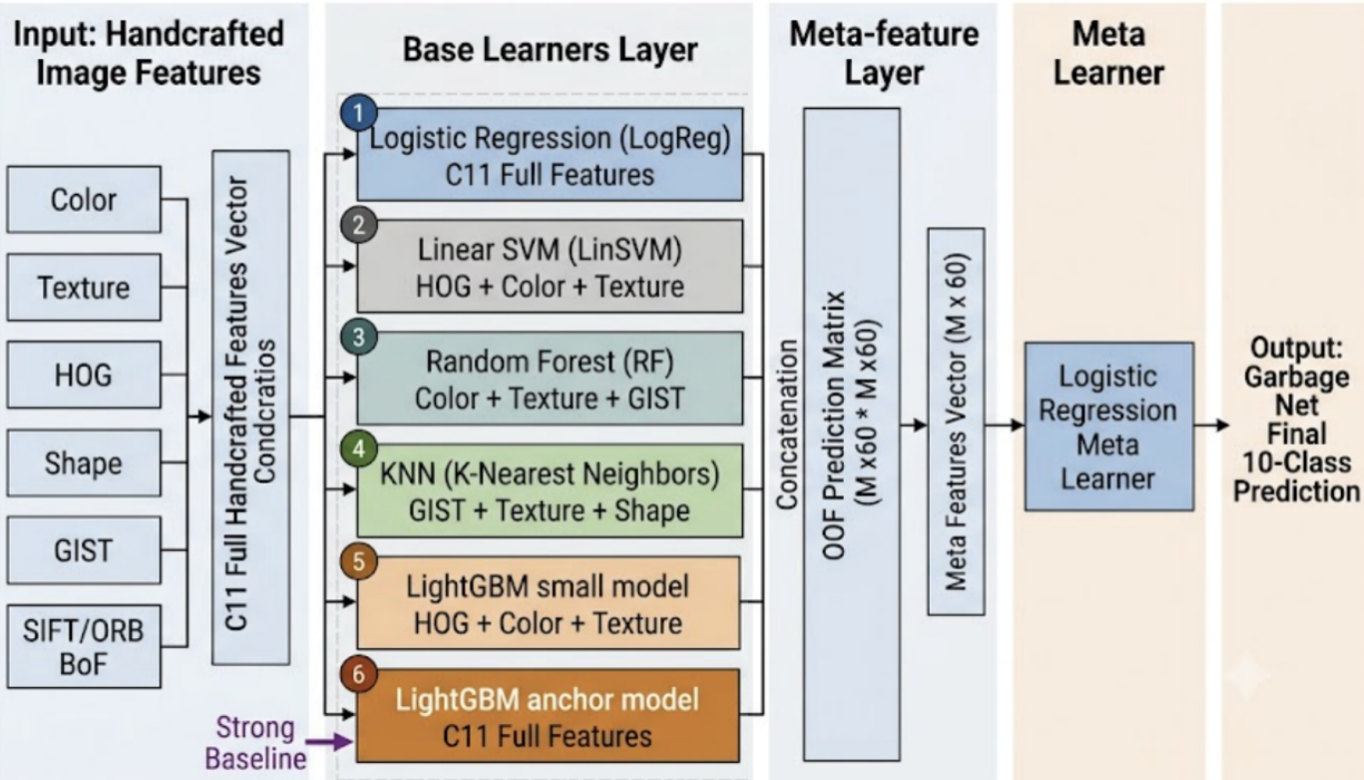

<center><b>Figure 1: Garbage Net Architecture</b></center>


## 1. 实验设计

本项目构建了一条可复现、可解释、能展示试错过程的建模链路。图像首先被转换为固定长度的特征向量，然后输入不同类型的传统机器学习模型。每个阶段的设计都对应一个具体问题：单一特征是否具有独立分类能力，哪些特征在少数类上更有价值，特征融合是否真正带来增益，强模型是否优于简单模型，类别权重是否改善不平衡问题，以及 stacking 是否能够利用不同模型之间的互补信息。

完整实验流程包括 9 个步骤。第一步是数据审查与固定划分，检查图像能否正常读取、类别数量是否一致、train/validation/test 是否保持分层比例。第二步是图像预处理，统一使用 `standardized_256` 图像版本，并根据特征需要转换为 RGB、BGR、HSV、Gray 和二值 mask 表示。第三步是特征提取，把每张图像表示为 F0-F6 不同特征组，其中 F1-F6 构成主要手工特征空间。第四步是固定参数单特征基线，用 Logistic Regression、KNN、Linear SVM 和 Decision Tree 观察每组特征的基础可分性。第五步是单特征候选调参，只对阶段四前有价值的组合做轻量搜索，避免无意义穷举。第六步是自适应特征融合与模型广筛。实验从 HOG 出发，逐步加入 Color、Texture、GIST、BoF 和 Shape，并在 14 个特征组合与 7 类模型上完成 98 组 validation 评价。第七步是强模型精调，主要比较 LightGBM 和 XGBoost 在短名单组合上的调参收益。第八步是 LightGBM 消融与类别不平衡处理，重点比较 no BoF、no Shape、no GIST、低维组合以及 `none`、`balanced`、`sqrt_balanced` 三类 sample weight。第九步是 stacking 集成，在单模型接近瓶颈后，用 5-fold OOF 预测训练 meta learner，最终确定 Garbage Net。

指标设计以 macro-F1 为主，因为 macro-F1 对每个类别等权，不会被 clothes、glass、plastic 等大类主导。accuracy 和 weighted-F1 用于观察整体分类正确率与样本加权表现；少数类 recall 均值用于衡量 trash、battery、biological 三类的召回能力。validation 集承担模型选择、调参和消融比较职责；test 集只在最终模型确定后使用，避免出现面向 test 的反复调参。

预先设定的评价标准贯穿所有阶段。所有中间表格中的 `validation_macro_f1` 用于选择方案，所有最终表格中的 `test_macro_f1` 用于报告最终泛化。少数类 recall 均值固定取 trash、battery、biological 三类，是因为这三类在样本量、视觉稳定性和实际错误成本上都更需要关注。若某方案 macro-F1 提升但少数类 recall 大幅下降，则不会被直接采纳。


## 2. 论文综述与方法定位
为了保证本项目不是简单的已有论文复现，我特意选择了一个非常新的2026年数据集：The Garbage Dataset (GD): A Multi-Class Image Benchmark for Automated Waste Segregation.这个数据集原本就是为神经网络设计的，且面世时间很短，只有神经网络的研究，没有传统机器学习方法的研究。其他相关研究只能起到方法借鉴作用。因此不必顾虑本项目的创新性与先射箭后画靶的风险。

图像垃圾分类是计算机视觉在智能回收和自动化垃圾分拣中的典型应用。已有研究主要采用三类方法：第一类是手工特征与传统机器学习分类器，第二类是端到端卷积神经网络或迁移学习模型，第三类是使用深度模型提取 embedding 后再接传统分类器的混合方法。本项目聚焦第一类路线。

Yang 和 Thung（2016）的 [Classification of Trash for Recyclability Status](https://cs229.stanford.edu/proj2016/report/ThungYang-ClassificationOfTrashForRecyclabilityStatus-report.pdf) 是较早的垃圾图像分类研究之一。该研究基于 TrashNet，将垃圾划分为 glass、paper、metal、plastic、cardboard 和 trash 六类，使用 SIFT 局部关键点、Bag of Features 视觉词袋和 RBF 核 SVM 进行分类，并与 CNN 进行比较。该工作对本项目有两点启发：其一，垃圾图像中材料纹理、局部关键点和形状边缘具有重要判别信息，因此本项目保留了 SIFT/ORB BoF 与 HOG；其二，trash 类样本少且视觉差异大，容易成为召回短板，因此本项目在评价指标中单独关注少数类 recall，而不只看 accuracy。

Nguyen 等人的 [Towards Accurate and Efficient Waste Image Classification](https://arxiv.org/abs/2510.21833) 系统比较了手工特征、深度学习和混合方案，手工特征部分覆盖颜色、形状、纹理、关键点和 GIST 等描述子，并使用传统分类器进行建模。这一思路直接指导了本项目的特征体系设计：F1 使用 HSV/BGR 颜色直方图和统计量，F2 使用 GLCM 与 LBP 纹理，F4 使用几何形状和 Hu moments，F5 使用 GIST，全局和局部信息同时进入候选空间。Sen 等人的 [Feature Engineering is Not Dead](https://arxiv.org/abs/2507.13772) 进一步说明，在需要可解释性和较低计算成本的图像分类任务中，HOG、LBP 等手工特征与 SVM 等传统模型仍具有研究价值。Mboli 和 Ogungbemi（2026）的 [AI-Enabled Waste Classification](https://arxiv.org/abs/2601.22418) 则比较了传统机器学习、PCA 与深度学习模型，提示降维并不一定稳定提升传统模型，特征选择必须结合具体模型和数据验证。

本项目不把非线性核 SVM 作为主体模型继续深入，原因包括研究重复性和计算成本两方面。首先，Yang 和 Thung 已经在垃圾分类任务中系统尝试了 SIFT/BoF + RBF-SVM，并给出了 RBF 核、C=1000、gamma=0.5 的设置；本项目的文献复刻也实现了 `yang_thung_2016_sift_bof_rbf_svm`，validation macro-F1 为 0.4240，少数类 recall 均值为 0.4599，明显低于后续 LightGBM、XGBoost 和 stacking 方案。其次，核 SVM 的训练和预测通常依赖样本间核矩阵及支持向量计算，在本项目 8581 个 train 样本、3165 维全量手工特征、98 组广筛实验的规模下，不适合作为大规模主线搜索模型。相比之下，线性 SVM 可通过 SGDClassifier 扩展到高维特征，并能作为 stacking 中的异质 base learner。因此，本项目将 SVM 路线限制在线性核和文献复刻对照中，把主要搜索资源投入到更可扩展、表现更强的树集成模型与 stacking 集成上。

文献综述还限定了本项目的边界。深度学习和混合深度特征方法在已有研究中具有更高性能上限，但它们往往需要更复杂的训练环境、更多调参和更强硬件。本项目的研究重点是传统机器学习条件下的完整建模流程，因此不会把深度学习作为主体实验。非线性核 SVM 同样不作为主线：其历史基准已经存在，本地复刻表现也不强，而广筛阶段需要在大量特征组合上重复训练，核方法的计算结构与本项目规模不匹配。

文献综述对本项目的实际作用体现在特征和模型两个层面。特征层面，已有研究支持颜色、纹理、形状、局部关键点和全局结构共同建模，因此 F1-F6 被设计为互补特征组。模型层面，已有研究显示 boosting 和传统分类器仍有价值，但非线性核 SVM 已被早期垃圾分类工作充分尝试，因此本项目把它作为复刻对照而非主线创新点。


## 3. 数据集介绍与固定划分

数据集目录包含三个源文件夹：`original`、`standardized_256` 和 `standardized_384`。`original` 保存原始图像版本，主要用于数据来源追溯、质量检查和示例展示；该版本保留了原图尺寸差异，适合观察真实图像状态，但不适合作为传统机器学习的直接输入，因为尺寸不统一会导致特征长度不一致。`standardized_384` 是较高分辨率的标准化版本，适合需要更多空间细节的模型，例如后续如果扩展到深度学习或更高分辨率特征提取，可以作为候选输入。`standardized_256` 是本项目的正式建模版本，所有图像被统一到 256×256，既保留了足够的颜色、边缘、纹理和局部关键点信息，又能控制 HOG、GIST、BoF 等特征提取的计算成本。

三个源文件夹都覆盖相同的 10 个类别，并对应 12259 张有效图像。正式建模选择 `standardized_256` 的原因有三点。第一，传统机器学习需要每张图像转换为固定长度向量，统一尺寸可以避免额外插值和裁剪策略在不同实验间不一致。第二，256×256 对 HOG 和 SIFT/ORB BoF 较为合适：HOG 可以在下采样到 128×128 后提取 1764 维梯度方向特征，SIFT/ORB 可以在可接受时间内形成视觉词袋。第三，384×384 虽然保留更多细节，但会显著增加关键点检测、局部描述子聚类和像素类 baseline 的计算量；在本项目强调分阶段多模型比较的设置下，256 版本更适合作为统一输入。

类别分布存在明显不均衡。clothes 有 1892 张，glass 有 1736 张，plastic 有 1597 张，shoes 有 1449 张，cardboard 有 1411 张，paper 有 1336 张；相对少数类包括 metal 930 张、battery 756 张、biological 699 张，trash 只有 453 张。固定划分采用 train / validation / test = 70% / 15% / 15% 的分层策略，最终 train 为 8581 张、validation 为 1839 张、test 为 1839 张。每个类别在三个 split 中保持近似相同比例，例如 trash 被划分为 train 317、validation 68、test 68，battery 被划分为 train 530、validation 113、test 113。这样的固定划分保证所有模型和特征组合在完全相同的数据条件下比较。validation 集用于模型筛选、特征组合比较、参数调整和 stacking 方案选择；test 集不参与任何中间决策，只在最终模型 Garbage Net 确定后使用一次。

数据划分采用固定随机种子和分层抽样，目的是把实验差异尽量限制在特征、模型和参数本身。若每个阶段重新划分数据，validation 波动会掩盖真实模型差异，也会使单特征、融合、消融和 stacking 的结果难以横向比较。固定 split 因此是整个实验的基础。


**类别与固定划分统计**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>class</th>
      <th>total</th>
      <th>train</th>
      <th>validation</th>
      <th>test</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>battery</td>
      <td>756</td>
      <td>530</td>
      <td>113</td>
      <td>113</td>
    </tr>
    <tr>
      <th>1</th>
      <td>biological</td>
      <td>699</td>
      <td>489</td>
      <td>105</td>
      <td>105</td>
    </tr>
    <tr>
      <th>2</th>
      <td>cardboard</td>
      <td>1411</td>
      <td>987</td>
      <td>212</td>
      <td>212</td>
    </tr>
    <tr>
      <th>3</th>
      <td>clothes</td>
      <td>1892</td>
      <td>1324</td>
      <td>284</td>
      <td>284</td>
    </tr>
    <tr>
      <th>4</th>
      <td>glass</td>
      <td>1736</td>
      <td>1216</td>
      <td>260</td>
      <td>260</td>
    </tr>
    <tr>
      <th>5</th>
      <td>metal</td>
      <td>930</td>
      <td>650</td>
      <td>140</td>
      <td>140</td>
    </tr>
    <tr>
      <th>6</th>
      <td>paper</td>
      <td>1336</td>
      <td>936</td>
      <td>200</td>
      <td>200</td>
    </tr>
    <tr>
      <th>7</th>
      <td>plastic</td>
      <td>1597</td>
      <td>1117</td>
      <td>240</td>
      <td>240</td>
    </tr>
    <tr>
      <th>8</th>
      <td>shoes</td>
      <td>1449</td>
      <td>1015</td>
      <td>217</td>
      <td>217</td>
    </tr>
    <tr>
      <th>9</th>
      <td>trash</td>
      <td>453</td>
      <td>317</td>
      <td>68</td>
      <td>68</td>
    </tr>
  </tbody>
</table>
</div>

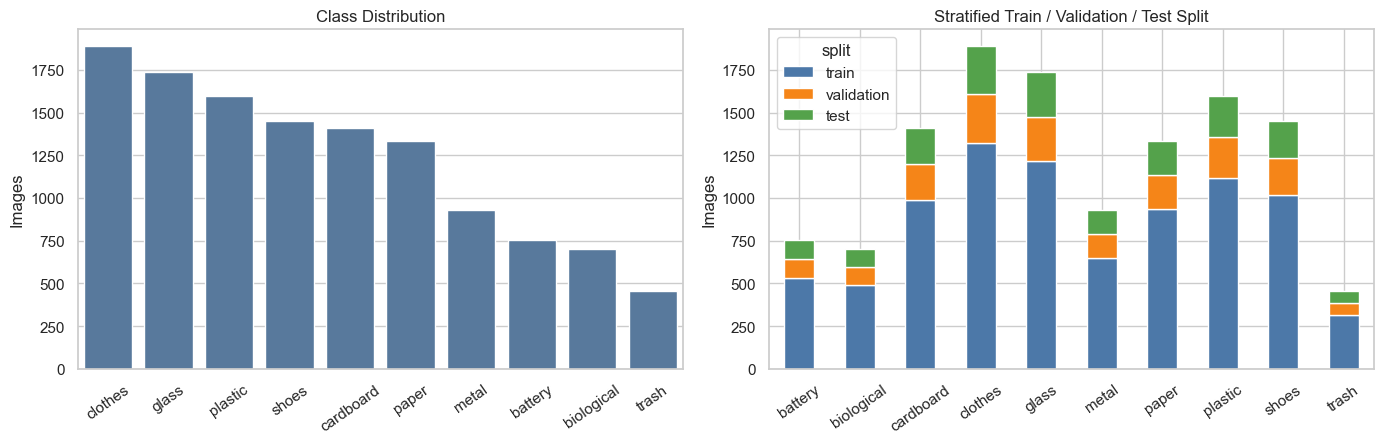

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>total_images</th>
      <th>train</th>
      <th>validation</th>
      <th>test</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>12259</td>
      <td>8581</td>
      <td>1839</td>
      <td>1839</td>
    </tr>
  </tbody>
</table>
</div>


## 4. 图像预处理与特征体系

图像预处理的目标是把非结构化图像转换为稳定、可复现的结构化特征。正式输入来自 `standardized_256`，每张图像统一为 256×256。根据不同特征的需求，预处理阶段生成 RGB、BGR、HSV、Gray 和近似前景 mask 等表示。颜色特征主要使用 HSV 与 BGR；纹理、HOG 和 GIST 主要依赖灰度图；形状特征使用阈值化和边缘信息近似主体区域；SIFT/ORB BoF 则从局部关键点描述子出发，经训练集视觉词典转换为固定长度词频向量。

特征体系分为七组：

F0 ：原始像素 baseline，包括 32×32 灰度像素 1024 维和 32×32 RGB 像素 3072 维，仅用于观察直接像素输入的最低基线。

F1 ：颜色特征，共 1039 维，由 HSV 统计量和 HSV/BGR 三维颜色直方图组成，主要描述材料颜色、亮度和饱和度分布。

F2 ：纹理特征，共 30 维，包括 GLCM 的 contrast、dissimilarity、homogeneity、energy、correlation 等统计量以及 LBP 直方图，用于描述纸张、纸板、布料、金属和塑料表面的局部模式。

F3 ：HOG 特征，共 1764 维，用于捕捉边缘方向和局部轮廓结构，是单特征阶段表现最强的主干特征。

F4 ：形状特征，共 12 维，包括面积、周长、长宽比以及 Hu moments 等几何信息。虽然 F4 单独分类能力不强，但其维度低、成本小，可以作为全量融合中的补充项。

F5 ： GIST 全局结构特征，共 64 维，描述图像整体空间布局和方向响应。

F6 ： SIFT+ORB Bag-of-Features，共 256 维，其中 SIFT 视觉词典 128 维、ORB 视觉词典 128 维，主要描述局部关键点和材料局部结构。

最终全量手工特征 C11 为 F1+F2+F4+F5+F3+F6，总维度 3165。

特征维度也反映了后续模型选择的难度。F3 HOG 1764 维和 F1 Color 1039 维占据主要维度，二者拼接后已经达到 2803 维；加入 Texture 后为 2833 维，加入 GIST、Shape、BoF 后最终达到 3165 维。高维连续特征对 KNN 和核 SVM 的计算较不友好，但对 LightGBM 这类基于树的 boosting 模型较合适，因为树模型可以通过分裂规则自动选择有效特征区间。低维特征如 F2、F4、F5 虽然单独信息有限，却能在融合和 stacking 中提供补充视角。

每一组特征都承担明确语义。颜色特征适合区分 biological、glass、plastic 等颜色分布明显的类别；纹理特征适合纸张、纸板、布料和金属表面；HOG 负责主体边缘和轮廓；BoF 关注局部关键点；GIST 关注整体布局。后续模型性能差异本质上反映了这些语义信息被利用的程度。


**特征组与维度**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature_id</th>
      <th>role</th>
      <th>actual_dim</th>
      <th>train_shape</th>
      <th>validation_shape</th>
      <th>test_shape</th>
      <th>nan_count_total</th>
      <th>inf_count_total</th>
      <th>status</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>F0_pixels_gray</td>
      <td>C0 primary raw-pixel baseline</td>
      <td>1024</td>
      <td>8581x1024</td>
      <td>1839x1024</td>
      <td>1839x1024</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
    <tr>
      <th>1</th>
      <td>F0_pixels_rgb</td>
      <td>optional raw-pixel baseline</td>
      <td>3072</td>
      <td>8581x3072</td>
      <td>1839x3072</td>
      <td>1839x3072</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
    <tr>
      <th>2</th>
      <td>F1_color</td>
      <td>C1 color feature group</td>
      <td>1039</td>
      <td>8581x1039</td>
      <td>1839x1039</td>
      <td>1839x1039</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
    <tr>
      <th>3</th>
      <td>F2_texture</td>
      <td>C2 texture feature group</td>
      <td>30</td>
      <td>8581x30</td>
      <td>1839x30</td>
      <td>1839x30</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
    <tr>
      <th>4</th>
      <td>F3_hog</td>
      <td>C3 HOG edge feature group</td>
      <td>1764</td>
      <td>8581x1764</td>
      <td>1839x1764</td>
      <td>1839x1764</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
    <tr>
      <th>5</th>
      <td>F4_shape</td>
      <td>C4 shape feature group</td>
      <td>12</td>
      <td>8581x12</td>
      <td>1839x12</td>
      <td>1839x12</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
    <tr>
      <th>6</th>
      <td>F5_gist</td>
      <td>C5 GIST global structure feature group</td>
      <td>64</td>
      <td>8581x64</td>
      <td>1839x64</td>
      <td>1839x64</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
    <tr>
      <th>7</th>
      <td>F6_bof</td>
      <td>C6 full local BoF feature group</td>
      <td>256</td>
      <td>8581x256</td>
      <td>1839x256</td>
      <td>1839x256</td>
      <td>0</td>
      <td>0</td>
      <td>ok</td>
    </tr>
  </tbody>
</table>
</div>

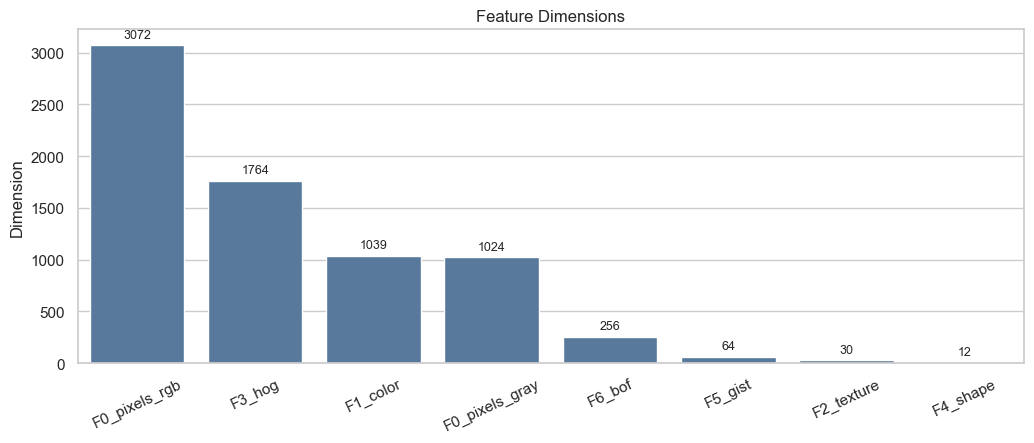

**预处理抽样检查图**

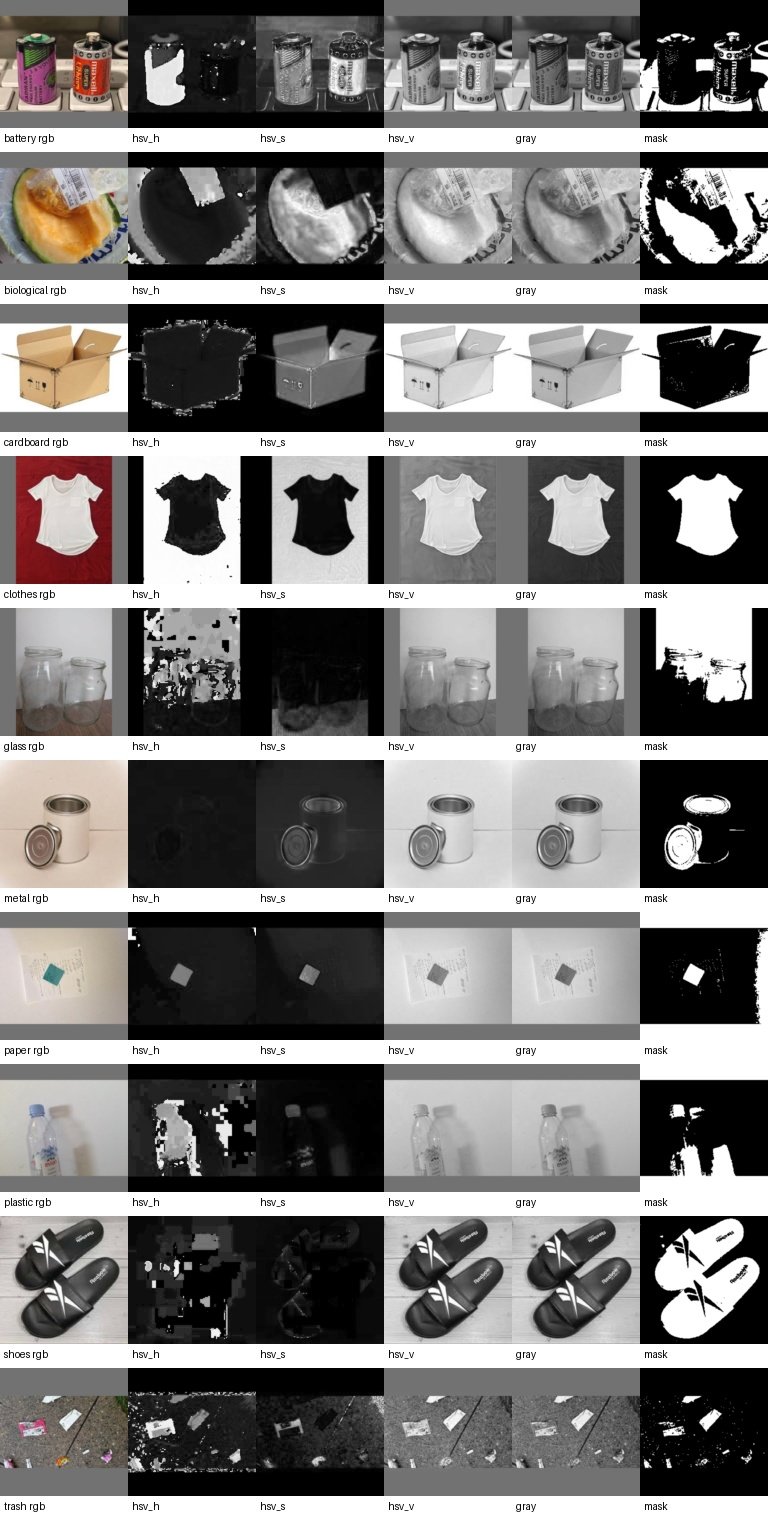


## 5. 阶段二：固定参数单特征基线

固定参数单特征基线用于回答第一个建模问题：在不调参、不融合的条件下，每组特征本身是否包含有效分类信息。该阶段使用 7 个单特征组和 4 类传统模型，共形成 28 组实验。模型选择覆盖线性、距离、最大间隔和树模型四种基础假设：Logistic Regression 用于检验线性可分性；KNN 用于检验局部邻域结构；Linear SVM 通过 hinge loss 检验高维线性间隔；Decision Tree 用于检验单棵树对非线性规则的表达能力。

固定参数设置保持简单且一致。Logistic Regression 使用 StandardScaler + `C=1`、`lbfgs`、`max_iter=1000`；KNN 使用 StandardScaler + `n_neighbors=5`、`weights=distance`、`metric=euclidean`；Linear SVM 使用 StandardScaler + `SGDClassifier(loss=hinge, alpha=0.0001, max_iter=1000)`；Decision Tree 使用默认树深度并固定 `random_state=42`。该阶段不追求最优参数，而是用统一规则判断特征价值。

输出结果显示，固定参数阶段的最佳组合是 F3 HOG + KNN，validation macro-F1 = 0.5163，少数类 recall 均值 = 0.4344。第二名是 F5 GIST + KNN，macro-F1 = 0.5037，少数类 recall = 0.4984。F2 Texture + Logistic Regression 的 macro-F1 = 0.4956，少数类 recall = 0.5555，说明低维纹理特征虽然整体区分能力不是最高，但对少数类较敏感。F1 Color + KNN 的 macro-F1 = 0.4816，少数类 recall = 0.5470，同样显示颜色分布对 battery、biological、trash 等类别有补充作用。

该阶段的结论是：HOG 是最强单特征，应作为后续融合起点；Color 和 Texture 在少数类召回上有明显价值，不能因为 macro-F1 略低而删除；GIST 维度低且表现稳定，可以作为全局结构补充；BoF 和 Shape 单独表现不突出，但需要在融合阶段继续验证是否具有互补性。散点图中的 macro-F1 与 minority recall 分布也显示，单一指标不足以支撑特征选择，必须同时观察整体表现和少数类表现。

从输出表可以看出，固定参数阶段并没有出现某一个特征全面领先所有指标的情况。HOG+KNN 的 macro-F1 最高，但少数类 recall 只有 0.4344；Texture+Logistic Regression 的 macro-F1 低于 HOG，但少数类 recall 达到 0.5555；Color+KNN 的少数类 recall 也达到 0.5470。这种差异说明，若只按 macro-F1 选择特征，可能会错过对少数类有帮助的颜色和纹理信息。因此后续融合不是简单取 top-1 特征，而是保留多种互补特征。

固定参数 baseline 的价值在于建立“朴素起点”。如果某个特征在简单模型和固定参数下已经完全无效，则后续继续投入大量搜索通常不划算；如果某个特征在部分指标上表现突出，即使总体排名不是第一，也应保留到融合阶段验证。阶段二结果正是以这种方式筛出了 HOG、Color、Texture、GIST 和 BoF。


**固定参数单特征 baseline Top 10**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature_id</th>
      <th>model</th>
      <th>feature_dim</th>
      <th>validation_accuracy</th>
      <th>validation_macro_f1</th>
      <th>minority_recall_mean</th>
      <th>recall_trash</th>
      <th>recall_battery</th>
      <th>recall_biological</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>F3_hog</td>
      <td>KNN</td>
      <td>1764</td>
      <td>0.5557</td>
      <td>0.5163</td>
      <td>0.4344</td>
      <td>0.4559</td>
      <td>0.6283</td>
      <td>0.2190</td>
    </tr>
    <tr>
      <th>1</th>
      <td>F5_gist</td>
      <td>KNN</td>
      <td>64</td>
      <td>0.5198</td>
      <td>0.5037</td>
      <td>0.4984</td>
      <td>0.5294</td>
      <td>0.5752</td>
      <td>0.3905</td>
    </tr>
    <tr>
      <th>2</th>
      <td>F2_texture</td>
      <td>LogisticRegression</td>
      <td>30</td>
      <td>0.5008</td>
      <td>0.4956</td>
      <td>0.5555</td>
      <td>0.3088</td>
      <td>0.6814</td>
      <td>0.6762</td>
    </tr>
    <tr>
      <th>3</th>
      <td>F2_texture</td>
      <td>KNN</td>
      <td>30</td>
      <td>0.5003</td>
      <td>0.4942</td>
      <td>0.5174</td>
      <td>0.4118</td>
      <td>0.5310</td>
      <td>0.6095</td>
    </tr>
    <tr>
      <th>4</th>
      <td>F1_color</td>
      <td>KNN</td>
      <td>1039</td>
      <td>0.4878</td>
      <td>0.4816</td>
      <td>0.5470</td>
      <td>0.5441</td>
      <td>0.4779</td>
      <td>0.6190</td>
    </tr>
    <tr>
      <th>5</th>
      <td>F1_color</td>
      <td>LogisticRegression</td>
      <td>1039</td>
      <td>0.4666</td>
      <td>0.4618</td>
      <td>0.5210</td>
      <td>0.3824</td>
      <td>0.6283</td>
      <td>0.5524</td>
    </tr>
    <tr>
      <th>6</th>
      <td>F3_hog</td>
      <td>LogisticRegression</td>
      <td>1764</td>
      <td>0.4736</td>
      <td>0.4360</td>
      <td>0.3486</td>
      <td>0.3088</td>
      <td>0.4513</td>
      <td>0.2857</td>
    </tr>
    <tr>
      <th>7</th>
      <td>F6_bof</td>
      <td>LogisticRegression</td>
      <td>256</td>
      <td>0.4345</td>
      <td>0.4235</td>
      <td>0.4472</td>
      <td>0.2794</td>
      <td>0.5575</td>
      <td>0.5048</td>
    </tr>
    <tr>
      <th>8</th>
      <td>F1_color</td>
      <td>DecisionTree</td>
      <td>1039</td>
      <td>0.4279</td>
      <td>0.4176</td>
      <td>0.4380</td>
      <td>0.3382</td>
      <td>0.5664</td>
      <td>0.4095</td>
    </tr>
    <tr>
      <th>9</th>
      <td>F1_color</td>
      <td>LinearSVM_SGD</td>
      <td>1039</td>
      <td>0.4318</td>
      <td>0.4166</td>
      <td>0.3943</td>
      <td>0.2500</td>
      <td>0.5044</td>
      <td>0.4286</td>
    </tr>
  </tbody>
</table>
</div>

**每组特征的最佳固定参数结果**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature_id</th>
      <th>model</th>
      <th>feature_dim</th>
      <th>validation_macro_f1</th>
      <th>minority_recall_mean</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>F3_hog</td>
      <td>KNN</td>
      <td>1764</td>
      <td>0.5163</td>
      <td>0.4344</td>
    </tr>
    <tr>
      <th>1</th>
      <td>F5_gist</td>
      <td>KNN</td>
      <td>64</td>
      <td>0.5037</td>
      <td>0.4984</td>
    </tr>
    <tr>
      <th>2</th>
      <td>F2_texture</td>
      <td>LogisticRegression</td>
      <td>30</td>
      <td>0.4956</td>
      <td>0.5555</td>
    </tr>
    <tr>
      <th>3</th>
      <td>F1_color</td>
      <td>KNN</td>
      <td>1039</td>
      <td>0.4816</td>
      <td>0.5470</td>
    </tr>
    <tr>
      <th>4</th>
      <td>F6_bof</td>
      <td>LogisticRegression</td>
      <td>256</td>
      <td>0.4235</td>
      <td>0.4472</td>
    </tr>
    <tr>
      <th>5</th>
      <td>F0_pixels_gray</td>
      <td>KNN</td>
      <td>1024</td>
      <td>0.4049</td>
      <td>0.3153</td>
    </tr>
    <tr>
      <th>6</th>
      <td>F4_shape</td>
      <td>KNN</td>
      <td>12</td>
      <td>0.2936</td>
      <td>0.2684</td>
    </tr>
  </tbody>
</table>
</div>

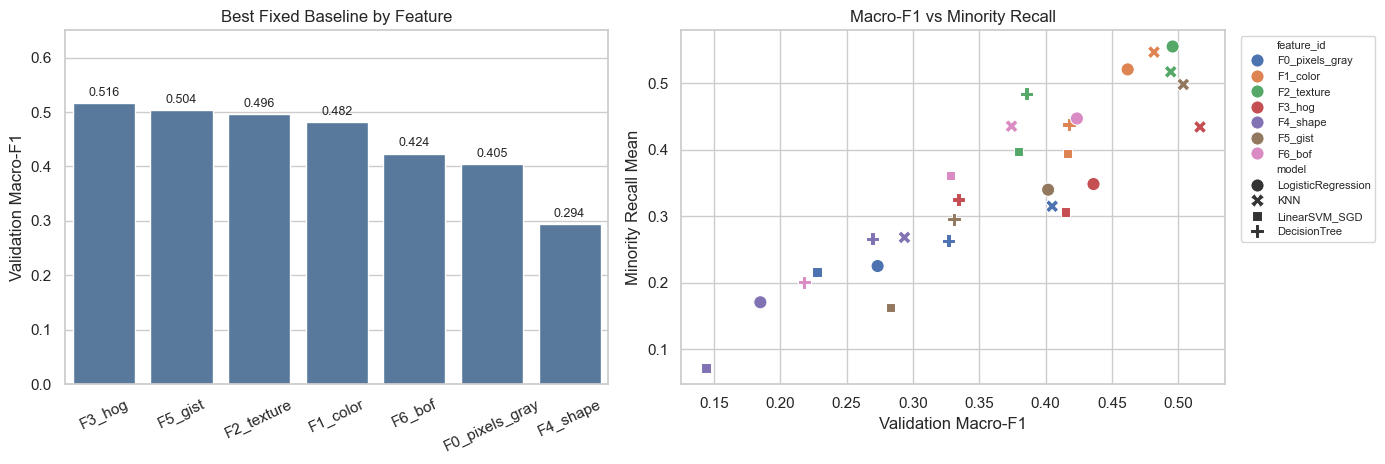


## 6. 阶段二补充：单特征候选调参

固定参数结果提供了第一轮筛选依据，但固定参数可能低估某些特征的潜力。因此阶段二补充实验只对 14 个有价值候选进行轻量调参，而不是对所有特征、模型和参数做全量穷举。筛选标准包括：固定参数 macro-F1 排名前列、少数类 recall 表现较好、或在特征含义上可能与其他特征互补。这样既能展示调参过程，又能避免把大量计算浪费在明显较弱的组合上。

调参策略根据特征维度和模型成本区别设计。高维 KNN 的距离计算较重，因此 HOG、Color、BoF、Gray pixel 等高维组合使用 train 内部 holdout 或 subsample；Texture、GIST 等低维组合使用 3-fold CV。SVM 搜索空间在试验中被收窄为线性 hinge + l2 方向，因为高维图像特征上的大规模 SVM 搜索非常耗时，且非线性核 SVM 已在文献中被充分尝试，不适合作为本项目后续主线。

调参后，F3 HOG + KNN 从固定参数 macro-F1 = 0.5163 提升到 0.5612，最佳参数为 Normalizer + `k=9`、manhattan 距离、distance 权重，是最强单特征结果。F2 Texture + KNN 得到 macro-F1 = 0.5024，少数类 recall = 0.5081，说明纹理特征在低维空间中仍较稳定。F1 Color + KNN 的 macro-F1 = 0.4980，但少数类 recall = 0.5620，是单特征中少数类召回最突出的组合。F5 GIST + KNN 得到 macro-F1 = 0.4942；F6 BoF + KNN 虽然 macro-F1 只有 0.4324，但少数类 recall = 0.4957，说明局部词袋可能对部分少数类有补充价值。

由此形成后续融合策略：以 HOG 为主干，优先加入 Color 和 Texture；GIST 作为低维全局结构补充；BoF 不因单独较弱而直接舍弃，而是在融合模型中验证其边际贡献；Shape 维度很低、成本小，也保留到消融实验中判断其最终价值。

调参输出还说明，模型参数会改变特征表现。HOG+KNN 从欧氏距离、k=5 调整到 manhattan 距离、k=9、distance 权重后，macro-F1 提升到 0.5612；Color+KNN 使用 MinMaxScaler、cosine 距离、k=11 后，更适合颜色直方图这类非负分布特征；Texture+KNN 使用 RobustScaler 后，可以降低纹理统计量中异常值对距离计算的影响。这些结果表明，传统机器学习中的 preprocessing 与模型参数同样重要，不能只讨论分类器名称。

调参阶段采用受控搜索。这样做能节省有限的算力，专注进行重要决策，而不是让随机搜索主导结果。调参输出中保留 `search_strategy`、`cv_macro_f1_mean`、`validation_macro_f1` 和 `best_params`，可以追踪每个候选为何被保留或舍弃。


**单特征调参后的最佳结果**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature_id</th>
      <th>model</th>
      <th>feature_dim</th>
      <th>fixed_validation_macro_f1</th>
      <th>validation_macro_f1</th>
      <th>minority_recall_mean</th>
      <th>search_strategy</th>
      <th>best_params_short</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>F3_hog</td>
      <td>KNN</td>
      <td>1764</td>
      <td>0.5163</td>
      <td>0.5612</td>
      <td>0.5208</td>
      <td>train_internal_holdout_subsample</td>
      <td>{"model__metric": "manhattan", "model__n_neighbors": 9, "model__weights": "d...</td>
    </tr>
    <tr>
      <th>1</th>
      <td>F2_texture</td>
      <td>KNN</td>
      <td>30</td>
      <td>0.4942</td>
      <td>0.5024</td>
      <td>0.5081</td>
      <td>stratified_3fold_cv</td>
      <td>{"model__metric": "euclidean", "model__n_neighbors": 11, "model__weights": "...</td>
    </tr>
    <tr>
      <th>2</th>
      <td>F1_color</td>
      <td>KNN</td>
      <td>1039</td>
      <td>0.4816</td>
      <td>0.4980</td>
      <td>0.5620</td>
      <td>train_internal_holdout_subsample</td>
      <td>{"model__metric": "cosine", "model__n_neighbors": 11, "model__weights": "dis...</td>
    </tr>
    <tr>
      <th>3</th>
      <td>F5_gist</td>
      <td>KNN</td>
      <td>64</td>
      <td>0.5037</td>
      <td>0.4942</td>
      <td>0.4969</td>
      <td>stratified_3fold_cv</td>
      <td>{"model__metric": "manhattan", "model__n_neighbors": 3, "model__weights": "d...</td>
    </tr>
    <tr>
      <th>4</th>
      <td>F6_bof</td>
      <td>KNN</td>
      <td>256</td>
      <td>0.3743</td>
      <td>0.4324</td>
      <td>0.4957</td>
      <td>train_internal_holdout</td>
      <td>{"model__metric": "cosine", "model__n_neighbors": 31, "model__weights": "dis...</td>
    </tr>
    <tr>
      <th>5</th>
      <td>F0_pixels_gray</td>
      <td>KNN</td>
      <td>1024</td>
      <td>0.4049</td>
      <td>0.4317</td>
      <td>0.3524</td>
      <td>train_internal_holdout_subsample</td>
      <td>{"model__metric": "manhattan", "model__n_neighbors": 1, "model__weights": "u...</td>
    </tr>
  </tbody>
</table>
</div>

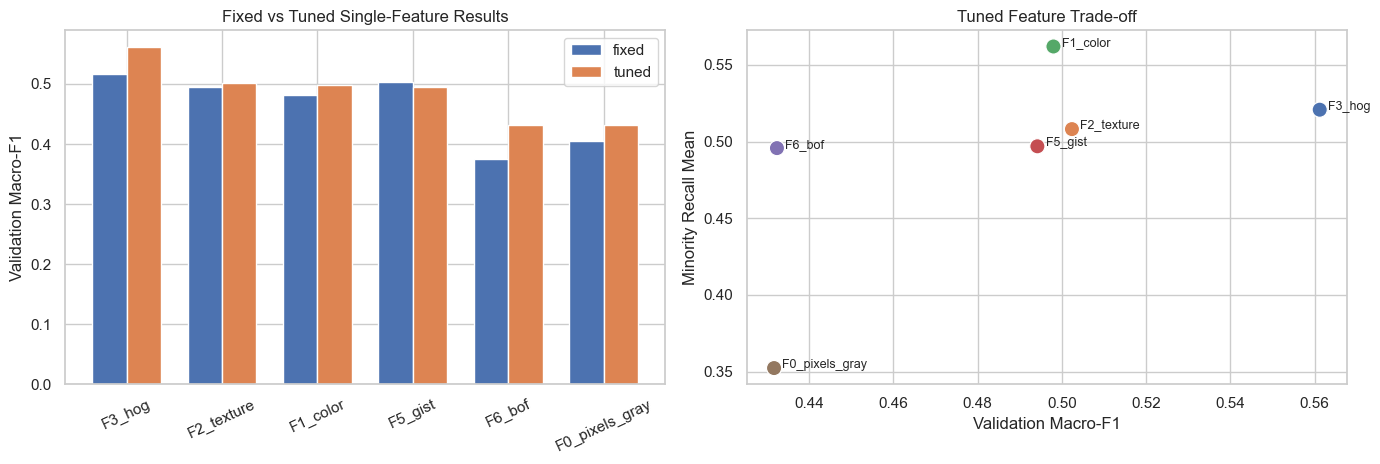


## 7. 阶段三：自适应特征融合与模型广筛

阶段三的目标是从单特征判断进入多特征建模。实验没有直接把所有特征拼接后训练一个模型，而是采用自适应融合策略：先以阶段二表现最强的 HOG 为起点，再根据少数类贡献和特征互补性逐步加入 Color、Texture、GIST、BoF 和 Shape。这样可以观察每一次加入特征后的边际变化，并避免“全量特征最好”这一结论缺乏过程依据。

本阶段共完成 14 个特征组合 × 7 类模型 = 98 组实验。模型族覆盖 Logistic Regression、KNN、Linear SVM、Decision Tree、Random Forest、XGBoost 和 LightGBM。线性模型用于提供可解释的高维基线；KNN 用于保留距离式局部结构判断；Decision Tree 和 Random Forest 用于观察树模型对非线性特征交互的处理能力；XGBoost 与 LightGBM 代表梯度提升树，是本阶段最重要的强模型候选。

输出结果显示，LightGBM 明显领先。C11 全量手工特征 + LightGBM 的 validation macro-F1 = 0.8096，少数类 recall 均值 = 0.8158，是阶段三最优结果。去掉 Shape 的 F3+F1+F2+F5+F6 + LightGBM 得到 macro-F1 = 0.8071，少数类 recall = 0.8109；C10 no BoF + LightGBM 得到 macro-F1 = 0.8020，少数类 recall = 0.7961；仅使用 HOG+Color+Texture 的 LightGBM 已达到 macro-F1 = 0.8012，少数类 recall = 0.8006。这说明 HOG、颜色和纹理构成主要信息来源，而 BoF 和 Shape 则提供进一步增益。

按模型族比较，LightGBM 的最佳 macro-F1 = 0.8096，XGBoost 次之，最佳 macro-F1 = 0.7980，Random Forest 最佳为 0.7049，Linear SVM 最佳为 0.6885，Logistic Regression 最佳为 0.6688，KNN 最佳为 0.5787，Decision Tree 最佳为 0.4705。该结果表明，高维混合手工特征包含复杂的非线性关系，单一线性模型和单棵树不足以充分利用这些信息；梯度提升树更适合处理不同尺度、不同语义来源的拼接特征。因此，后续阶段将 LightGBM 作为主模型，同时保留 XGBoost 和若干小模型作为对照或 stacking 候选。

阶段三热力图用于观察两个维度的规律。沿模型维度看，LightGBM 在大多数强特征组合上领先，说明它对混合特征的非线性建模能力更强；沿特征维度看，从 F3 到 F3+F1，再到 F3+F1+F2，macro-F1 持续上升，说明颜色和纹理不是冗余信息。C11 full 相比 HOG anchor 的 macro-F1 增益约 0.1728，少数类 recall 增益约 0.2228，是整个实验中最关键的性能跃迁之一。

阶段三中的 98 组实验构成了主模型选择的核心证据。若只比较最终 C11 组合，无法判断 Color、Texture、BoF、Shape 是否真的贡献有效信息；若只比较 LightGBM，无法说明其他模型族为何被排除。热力图把这两个维度同时展开，使模型选择具有可解释依据。


**阶段三广筛 Top 10**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>combo_id</th>
      <th>feature_ids</th>
      <th>model</th>
      <th>feature_dim</th>
      <th>validation_accuracy</th>
      <th>validation_macro_f1</th>
      <th>minority_recall_mean</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>S3_13_C11_reference_full_handcrafted</td>
      <td>F1_color+F2_texture+F4_shape+F5_gist+F3_hog+F6_bof</td>
      <td>LightGBM</td>
      <td>3165</td>
      <td>0.8157</td>
      <td>0.8096</td>
      <td>0.8158</td>
    </tr>
    <tr>
      <th>1</th>
      <td>S3_09_F3_hog__F1_color__F2_texture__F5_gist__F6_bof</td>
      <td>F3_hog+F1_color+F2_texture+F5_gist+F6_bof</td>
      <td>LightGBM</td>
      <td>3153</td>
      <td>0.8135</td>
      <td>0.8071</td>
      <td>0.8109</td>
    </tr>
    <tr>
      <th>2</th>
      <td>S3_12_C10_reference_no_bof</td>
      <td>F1_color+F2_texture+F4_shape+F5_gist+F3_hog</td>
      <td>LightGBM</td>
      <td>2909</td>
      <td>0.8091</td>
      <td>0.8020</td>
      <td>0.7961</td>
    </tr>
    <tr>
      <th>3</th>
      <td>S3_05_F3_hog__F1_color__F2_texture</td>
      <td>F3_hog+F1_color+F2_texture</td>
      <td>LightGBM</td>
      <td>2833</td>
      <td>0.8070</td>
      <td>0.8012</td>
      <td>0.8006</td>
    </tr>
    <tr>
      <th>4</th>
      <td>S3_09_F3_hog__F1_color__F2_texture__F5_gist__F6_bof</td>
      <td>F3_hog+F1_color+F2_texture+F5_gist+F6_bof</td>
      <td>XGBoost</td>
      <td>3153</td>
      <td>0.8021</td>
      <td>0.7980</td>
      <td>0.8140</td>
    </tr>
    <tr>
      <th>5</th>
      <td>S3_13_C11_reference_full_handcrafted</td>
      <td>F1_color+F2_texture+F4_shape+F5_gist+F3_hog+F6_bof</td>
      <td>XGBoost</td>
      <td>3165</td>
      <td>0.8015</td>
      <td>0.7974</td>
      <td>0.8079</td>
    </tr>
    <tr>
      <th>6</th>
      <td>S3_08_F3_hog__F1_color__F2_texture__F5_gist</td>
      <td>F3_hog+F1_color+F2_texture+F5_gist</td>
      <td>LightGBM</td>
      <td>2897</td>
      <td>0.8010</td>
      <td>0.7947</td>
      <td>0.7964</td>
    </tr>
    <tr>
      <th>7</th>
      <td>S3_11_F1_color__F2_texture__F5_gist</td>
      <td>F1_color+F2_texture+F5_gist</td>
      <td>LightGBM</td>
      <td>1133</td>
      <td>0.7868</td>
      <td>0.7845</td>
      <td>0.8104</td>
    </tr>
    <tr>
      <th>8</th>
      <td>S3_08_F3_hog__F1_color__F2_texture__F5_gist</td>
      <td>F3_hog+F1_color+F2_texture+F5_gist</td>
      <td>XGBoost</td>
      <td>2897</td>
      <td>0.7868</td>
      <td>0.7845</td>
      <td>0.8003</td>
    </tr>
    <tr>
      <th>9</th>
      <td>S3_05_F3_hog__F1_color__F2_texture</td>
      <td>F3_hog+F1_color+F2_texture</td>
      <td>XGBoost</td>
      <td>2833</td>
      <td>0.7858</td>
      <td>0.7811</td>
      <td>0.8010</td>
    </tr>
  </tbody>
</table>
</div>

**各模型族的最佳结果**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>combo_id</th>
      <th>feature_ids</th>
      <th>validation_macro_f1</th>
      <th>minority_recall_mean</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>LightGBM</td>
      <td>S3_13_C11_reference_full_handcrafted</td>
      <td>F1_color+F2_texture+F4_shape+F5_gist+F3_hog+F6_bof</td>
      <td>0.8096</td>
      <td>0.8158</td>
    </tr>
    <tr>
      <th>1</th>
      <td>XGBoost</td>
      <td>S3_09_F3_hog__F1_color__F2_texture__F5_gist__F6_bof</td>
      <td>F3_hog+F1_color+F2_texture+F5_gist+F6_bof</td>
      <td>0.7980</td>
      <td>0.8140</td>
    </tr>
    <tr>
      <th>2</th>
      <td>RandomForest</td>
      <td>S3_11_F1_color__F2_texture__F5_gist</td>
      <td>F1_color+F2_texture+F5_gist</td>
      <td>0.7049</td>
      <td>0.7604</td>
    </tr>
    <tr>
      <th>3</th>
      <td>LinearSVM_SGD</td>
      <td>S3_13_C11_reference_full_handcrafted</td>
      <td>F1_color+F2_texture+F4_shape+F5_gist+F3_hog+F6_bof</td>
      <td>0.6885</td>
      <td>0.7008</td>
    </tr>
    <tr>
      <th>4</th>
      <td>LogisticRegression</td>
      <td>S3_09_F3_hog__F1_color__F2_texture__F5_gist__F6_bof</td>
      <td>F3_hog+F1_color+F2_texture+F5_gist+F6_bof</td>
      <td>0.6688</td>
      <td>0.7118</td>
    </tr>
    <tr>
      <th>5</th>
      <td>KNN</td>
      <td>S3_03_F3_hog__F5_gist</td>
      <td>F3_hog+F5_gist</td>
      <td>0.5787</td>
      <td>0.5739</td>
    </tr>
    <tr>
      <th>6</th>
      <td>DecisionTree</td>
      <td>S3_12_C10_reference_no_bof</td>
      <td>F1_color+F2_texture+F4_shape+F5_gist+F3_hog</td>
      <td>0.4705</td>
      <td>0.5864</td>
    </tr>
  </tbody>
</table>
</div>

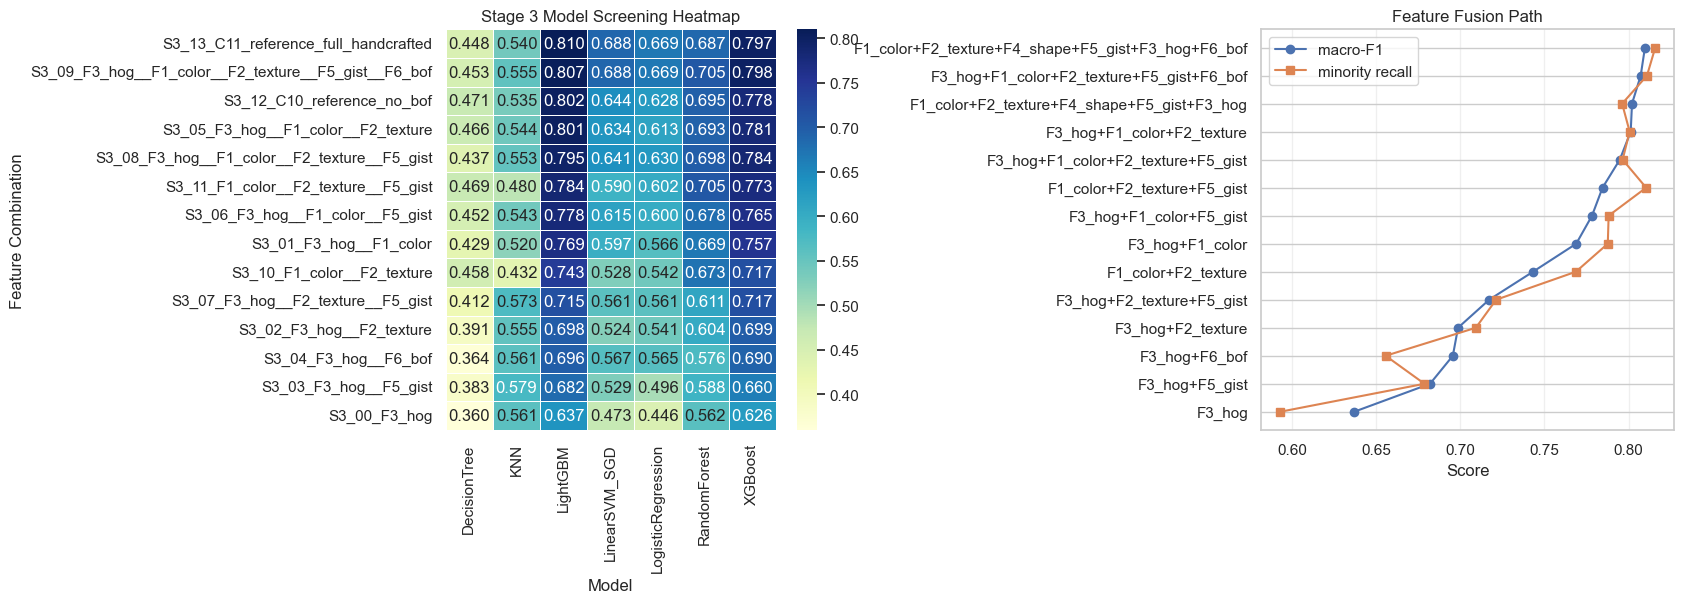


## 8. 阶段四（1）：强模型精调

阶段三已经确认 LightGBM 和 XGBoost 是最强模型族，因此阶段四首先对这两类 boosting 模型做有限精调。该阶段的目标不是重新开展无限制的参数搜索，而是在阶段三已经筛出的高价值特征组合上，检验更细的树模型参数、正则化参数、采样参数和类别权重是否还能带来稳定收益。由于 validation 集还要承担最终候选比较的职责，精调过程没有直接在 validation 上搜索参数，而是先在 train split 内部划分出一个小型搜索集，再把搜索得到的最佳参数回到完整 train split 上重训，最后只在 validation split 上评价一次。

具体流程分为六步。第一步，读取已经缓存好的 F1-F6 特征矩阵，并检查不同特征组的 image_id、label 和 split 顺序是否完全一致。第二步，根据候选配置拼接特征矩阵，并使用 `VarianceThreshold(threshold=0.0)` 在 train 上删除零方差特征，再对 validation 使用同一个 selector 变换；因此 C11 full 的原始 3165 维在精调表中变为 3147 维，no shape 组合从 3153 维变为 3135 维，HOG+Color+Texture 从 2833 维变为 2815 维，Color+Texture+GIST 从 1133 维变为 1115 维，no BoF 从 2909 维变为 2891 维。第三步，在 train split 内部进行分层 holdout：先按 75%/25% 划分 inner train 和 inner validation，再为控制耗时进行分层抽样，实际搜索使用 4200 个 inner-train 样本和 1400 个 inner-validation 样本。第四步，在 inner-train 上训练每个 trial，并在 inner-validation 上计算 macro-F1、macro precision、macro recall、weighted-F1 和少数类 recall 均值。第五步，以 inner macro-F1 为第一排序指标、inner 少数类 recall 均值为并列时的第二排序指标，选出每个候选的最佳 trial。第六步，将该 trial 的最佳迭代轮数写回 `n_estimators`，在完整 train split 上重新拟合，再对 validation split 做统一评价。

候选组合来自阶段三的短名单，共 7 个。LightGBM 部分包括 5 个候选：`LGBM_A_C11_full` 使用 F1_color+F2_texture+F4_shape+F5_gist+F3_hog+F6_bof，是阶段三 macro-F1 最高的全量手工特征组合；`LGBM_B_no_shape` 去掉 F4_shape，用来检验弱形状特征是否会拖累强模型；`LGBM_C_hog_color_texture` 只使用 HOG+Color+Texture，是主干紧凑组合；`LGBM_D_lowdim_color_texture_gist` 使用 Color+Texture+GIST，维度较低但阶段三少数类 recall 较好；`LGBM_E_no_bof` 去掉 BoF，用来观察局部词袋缺失时的表现。XGBoost 部分包括 2 个候选：`XGB_A_C11_full` 对应全量手工特征，`XGB_B_no_shape` 对应阶段三 XGBoost 表现最好的 no-shape 组合。这样设计可以同时比较“全量特征是否仍最优”“去掉弱特征是否更稳”“紧凑主干特征是否足够”“低维少数类友好组合是否值得保留”以及“XGBoost 能否追上 LightGBM”。

参数搜索采用“基准参数 + 随机采样”的紧凑策略。每个候选首先保留阶段三的基准参数作为 trial 1，随后使用固定随机种子从预设空间中抽样。实际保存的搜索结果中，5 个 LightGBM 候选各完成 6 个 trial，共 30 个 LightGBM trial；2 个 XGBoost 候选各完成 4 个 trial，共 8 个 XGBoost trial，合计 38 个 trial。LightGBM 的搜索空间包括 `n_estimators` ∈ {320, 460, 650, 800}、`num_leaves` ∈ {15, 31, 63, 95}、`max_depth` ∈ {-1, 6, 8, 10, 12}、`learning_rate` ∈ {0.03, 0.05, 0.07}、`min_child_samples` ∈ {10, 20, 40, 80}、`subsample` ∈ {0.75, 0.85, 1.0}、`colsample_bytree` ∈ {0.65, 0.75, 0.9, 1.0}、`reg_alpha` ∈ {0, 0.1, 0.5}、`reg_lambda` ∈ {0.5, 1.0, 2.0, 5.0}，并比较 `sample_weight_mode=None` 和 `balanced`。XGBoost 的搜索空间包括 `n_estimators` ∈ {260, 360, 500, 650}、`max_depth` ∈ {3, 4, 5, 6}、`learning_rate` ∈ {0.03, 0.05, 0.07}、`subsample` ∈ {0.75, 0.85, 1.0}、`colsample_bytree` ∈ {0.65, 0.75, 0.9}、`min_child_weight` ∈ {1, 3, 5}、`gamma` ∈ {0, 0.1, 0.3}、`reg_alpha` ∈ {0, 0.1, 0.5}、`reg_lambda` ∈ {1.0, 2.0, 5.0}，同样比较是否使用 balanced sample weight。

为了避免过长 trial 在 inner holdout 上继续训练，LightGBM 和 XGBoost 都使用 early stopping。LightGBM 在 inner-validation 上使用 `multi_logloss`，设置 early stopping rounds = 30；XGBoost 使用 `eval_metric=mlogloss`，同样设置 early stopping rounds = 30。每个 trial 记录 `best_iteration`，最终重训时不再使用 early stopping，而是直接把最佳轮数作为 `n_estimators`。这样做的原因是，validation split 需要保持为统一比较集，不能在最终重训时再次参与 early stopping，否则 validation 会同时承担参数选择和模型评价两种角色。

从 inner holdout 结果看，LightGBM 全量特征和 no-shape 组合最有竞争力。`LGBM_A_C11_full` 的最佳 trial 是 trial 3，inner macro-F1 = 0.7501，inner 少数类 recall = 0.7187，对应参数为 `learning_rate=0.03`、`max_depth=6`、`num_leaves=95`、`min_child_samples=80`、`n_estimators=460`、`colsample_bytree=0.9`、`subsample=1.0`、`reg_alpha=0.5`、`reg_lambda=1.0`、`sample_weight_mode=balanced`。`LGBM_B_no_shape` 的最佳 trial 也是 trial 3，inner macro-F1 = 0.7520，inner 少数类 recall = 0.7220，说明在 inner holdout 上去掉 shape 后略有优势。`LGBM_C_hog_color_texture` 的最佳 trial 是阶段三基准参数，inner macro-F1 = 0.7227；`LGBM_D_lowdim_color_texture_gist` 的最佳 trial inner macro-F1 = 0.7359；`LGBM_E_no_bof` 的最佳 trial inner macro-F1 = 0.7429。XGBoost 的两个候选中，基准 trial 反而最稳：`XGB_A_C11_full` inner macro-F1 = 0.7430，`XGB_B_no_shape` inner macro-F1 = 0.7433。

最终 validation 结果显示，inner holdout 的最优排序没有完全转化为 validation 最优。`LGBM_A_C11_full` 在完整 train 上重训后，validation macro-F1 = 0.8036，少数类 recall = 0.8272，相比阶段三同组合 macro-F1 = 0.8096 下降 0.0060，但少数类 recall 从 0.8158 提高到 0.8272。`LGBM_B_no_shape` 的 validation macro-F1 = 0.8000，少数类 recall = 0.8302，是本轮少数类 recall 最高的方案，但 macro-F1 比阶段三 no-shape 结果低 0.0071。`LGBM_C_hog_color_texture` 的 validation macro-F1 = 0.7863，低于阶段三 0.8012；`LGBM_D_lowdim_color_texture_gist` 为 0.7792，低于阶段三 0.7845；`LGBM_E_no_bof` 为 0.7908，低于阶段三 0.8020。XGBoost 中，`XGB_A_C11_full` 的 validation macro-F1 = 0.7996，比阶段三对应候选小幅提高 0.0022，但少数类 recall 降至 0.7795；`XGB_B_no_shape` 的 validation macro-F1 = 0.7959，低于阶段三 0.7980。

该阶段的结论是，第一轮强模型精调没有刷新阶段三最高的 validation macro-F1。调参确实改变了模型偏好，尤其是 balanced sample weight 往往提高 battery、biological、trash 等少数类的召回，但这种提升伴随着整体 macro-F1 的下降。由于本项目以 macro-F1 为主指标，不能仅因为少数类 recall 提高就替换主模型。精调阶段的负结果具有明确价值：它说明继续扩大随机搜索未必是最有效的方向，后续实验应转向更具解释性的 LightGBM 消融、类别不平衡处理，以及能够利用异质模型互补性的 stacking 集成。


**强模型精调后的 validation 结果**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>candidate_id</th>
      <th>model</th>
      <th>combo_label</th>
      <th>sample_weight_mode</th>
      <th>stage3_macro_f1</th>
      <th>validation_macro_f1</th>
      <th>macro_f1_delta_vs_stage3</th>
      <th>minority_recall_mean</th>
      <th>best_params_short</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>LGBM_A_C11_full</td>
      <td>LightGBM</td>
      <td>A_C11_full</td>
      <td>balanced</td>
      <td>0.8096</td>
      <td>0.8036</td>
      <td>-0.0060</td>
      <td>0.8272</td>
      <td>{"colsample_bytree": 0.9, "learning_rate": 0.03, "max_depth": 6, "min_child_...</td>
    </tr>
    <tr>
      <th>1</th>
      <td>LGBM_B_no_shape</td>
      <td>LightGBM</td>
      <td>B_no_shape</td>
      <td>balanced</td>
      <td>0.8071</td>
      <td>0.8000</td>
      <td>-0.0071</td>
      <td>0.8302</td>
      <td>{"colsample_bytree": 0.9, "learning_rate": 0.03, "max_depth": 6, "min_child_...</td>
    </tr>
    <tr>
      <th>2</th>
      <td>XGB_A_C11_full</td>
      <td>XGBoost</td>
      <td>A_C11_full</td>
      <td>NaN</td>
      <td>0.7974</td>
      <td>0.7996</td>
      <td>0.0022</td>
      <td>0.7795</td>
      <td>{"colsample_bytree": 0.75, "gamma": 0.0, "learning_rate": 0.055, "max_depth"...</td>
    </tr>
    <tr>
      <th>3</th>
      <td>XGB_B_no_shape</td>
      <td>XGBoost</td>
      <td>B_no_shape</td>
      <td>NaN</td>
      <td>0.7980</td>
      <td>0.7959</td>
      <td>-0.0021</td>
      <td>0.7827</td>
      <td>{"colsample_bytree": 0.75, "gamma": 0.0, "learning_rate": 0.055, "max_depth"...</td>
    </tr>
    <tr>
      <th>4</th>
      <td>LGBM_E_no_bof</td>
      <td>LightGBM</td>
      <td>E_no_bof</td>
      <td>balanced</td>
      <td>0.8020</td>
      <td>0.7908</td>
      <td>-0.0112</td>
      <td>0.7919</td>
      <td>{"colsample_bytree": 0.75, "learning_rate": 0.07, "max_depth": 10, "min_chil...</td>
    </tr>
    <tr>
      <th>5</th>
      <td>LGBM_C_hog_color_texture</td>
      <td>LightGBM</td>
      <td>C_hog_color_texture</td>
      <td>NaN</td>
      <td>0.8012</td>
      <td>0.7863</td>
      <td>-0.0149</td>
      <td>0.7815</td>
      <td>{"colsample_bytree": 0.75, "learning_rate": 0.05, "max_depth": -1, "min_chil...</td>
    </tr>
    <tr>
      <th>6</th>
      <td>LGBM_D_lowdim_color_texture_gist</td>
      <td>LightGBM</td>
      <td>D_lowdim_color_texture_gist</td>
      <td>balanced</td>
      <td>0.7845</td>
      <td>0.7792</td>
      <td>-0.0052</td>
      <td>0.7978</td>
      <td>{"colsample_bytree": 0.75, "learning_rate": 0.07, "max_depth": 10, "min_chil...</td>
    </tr>
  </tbody>
</table>
</div>

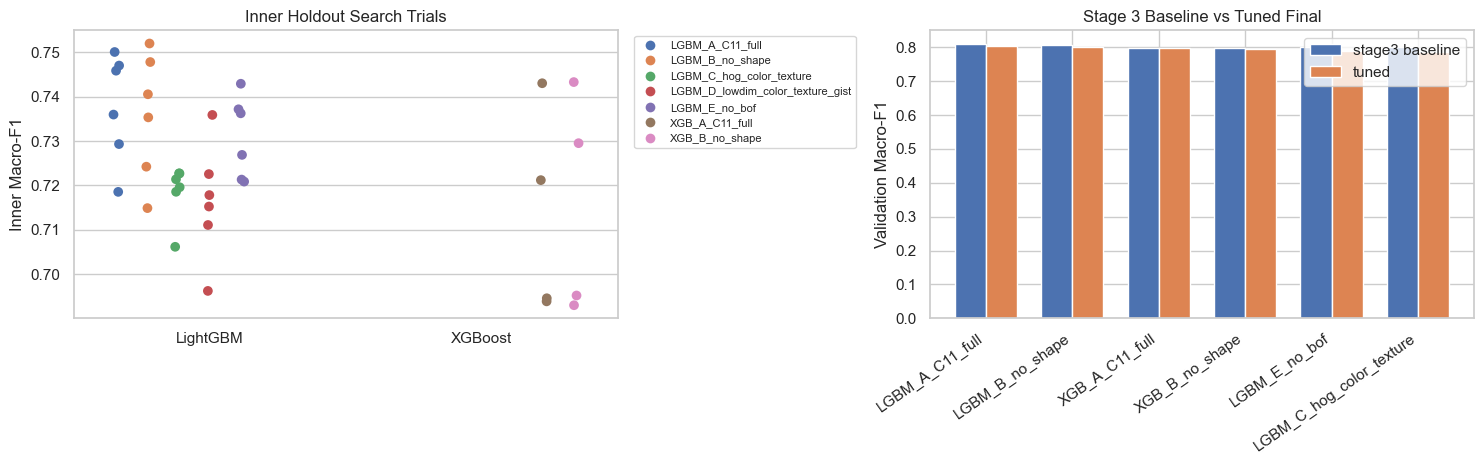


## 9. 阶段四（2）：LightGBM 消融与类别不平衡处理

本阶段固定阶段三表现稳定的 LightGBM 参数，即 `n_estimators=460`、`num_leaves=31`、`learning_rate=0.05`、`subsample=0.85`、`colsample_bytree=0.75`、`reg_lambda=1.0`，再比较不同特征组合和类别权重策略。这样可以把变量集中在“特征是否有贡献”和“权重是否改善不平衡”两个问题上，而不是让模型参数变化干扰解释。

特征消融结果显示，C11 full + balanced 的 validation macro-F1 = 0.8096，少数类 recall = 0.8158，作为消融基准。去掉 Shape 后 macro-F1 = 0.8071，下降 0.0025，说明 Shape 贡献较小但为正。去掉 BoF 后 macro-F1 = 0.8020，少数类 recall = 0.7961，较 C11 明显下降，说明 SIFT/ORB 局部词袋虽然单独表现一般，但在全量模型中提供了有用的局部结构补充。去掉 GIST 后 macro-F1 = 0.8054，但少数类 recall = 0.8221，说明 GIST 对整体 macro-F1 有帮助，但不同少数类之间存在取舍。仅使用 HOG+Color+Texture 的 macro-F1 = 0.8012，已经接近 C11，但仍低于全量特征。

类别不平衡处理比较了 `none`、`balanced` 和 `sqrt_balanced`。C11 full + none 的 validation macro-F1 = 0.8086，少数类 recall = 0.7888；C11 full + balanced 的 macro-F1 = 0.8096，少数类 recall = 0.8158；C11 full + sqrt_balanced 的 macro-F1 = 0.8131，少数类 recall = 0.8158。`sqrt_balanced` 对 balanced 权重开方后再归一化，相当于保留少数类补偿但降低极端权重，因此在本数据集上取得了更好的总体平衡。

该阶段最终确定 LightGBM C11 full + `sqrt_balanced` 作为最强单模型参考，其 validation macro-F1 = 0.8131。消融结果也为 stacking 设计提供依据：BoF、Shape、GIST 等特征可以保留在 anchor 或部分小模型中，但不必强制所有 base learner 都使用全量特征；低维 Color+Texture+GIST 虽然 macro-F1 较低，但少数类 recall 较高，适合作为异质 base learner。

消融表中的数值为最终特征选择提供了直接证据。no BoF 的下降幅度大于 no Shape，说明 BoF 的边际贡献更重要；lowdim Color+Texture+GIST 的 macro-F1 只有 0.7845，但少数类 recall 达到 0.8104，说明低维组合虽然整体弱于 C11，却对少数类有较好覆盖。类别权重表则显示 `sqrt_balanced` 比 `balanced` 更稳：它没有继续提高少数类 recall，但把 macro-F1 从 0.8096 提高到 0.8131，说明更温和的权重能减少过度补偿。

消融实验关注的是某组特征在强模型和融合环境中的边际价值。BoF 单独不强但消融后下降明显，正说明特征价值不能只由单特征结果决定；Shape 单独弱但删除后略降，说明低成本补充特征在全量模型中仍可能有用。


**LightGBM 特征消融结果**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>combo_id</th>
      <th>feature_dim_raw</th>
      <th>sample_weight_mode</th>
      <th>validation_macro_f1</th>
      <th>minority_recall_mean</th>
      <th>delta_macro_f1_vs_C11_none</th>
      <th>recall_trash</th>
      <th>recall_battery</th>
      <th>recall_biological</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>C11_full</td>
      <td>3165</td>
      <td>balanced</td>
      <td>0.8096</td>
      <td>0.8158</td>
      <td>0.0000</td>
      <td>0.7059</td>
      <td>0.8938</td>
      <td>0.8476</td>
    </tr>
    <tr>
      <th>1</th>
      <td>no_shape</td>
      <td>3153</td>
      <td>balanced</td>
      <td>0.8071</td>
      <td>0.8109</td>
      <td>-0.0025</td>
      <td>0.6912</td>
      <td>0.8938</td>
      <td>0.8476</td>
    </tr>
    <tr>
      <th>2</th>
      <td>no_gist</td>
      <td>3101</td>
      <td>balanced</td>
      <td>0.8054</td>
      <td>0.8221</td>
      <td>-0.0043</td>
      <td>0.7059</td>
      <td>0.8938</td>
      <td>0.8667</td>
    </tr>
    <tr>
      <th>3</th>
      <td>no_bof</td>
      <td>2909</td>
      <td>balanced</td>
      <td>0.8020</td>
      <td>0.7961</td>
      <td>-0.0077</td>
      <td>0.6912</td>
      <td>0.8496</td>
      <td>0.8476</td>
    </tr>
    <tr>
      <th>4</th>
      <td>hog_color_texture</td>
      <td>2833</td>
      <td>balanced</td>
      <td>0.8012</td>
      <td>0.8006</td>
      <td>-0.0085</td>
      <td>0.7059</td>
      <td>0.8673</td>
      <td>0.8286</td>
    </tr>
    <tr>
      <th>5</th>
      <td>no_shape_no_bof</td>
      <td>2897</td>
      <td>balanced</td>
      <td>0.7947</td>
      <td>0.7964</td>
      <td>-0.0149</td>
      <td>0.7206</td>
      <td>0.8496</td>
      <td>0.8190</td>
    </tr>
    <tr>
      <th>6</th>
      <td>lowdim_color_texture_gist</td>
      <td>1133</td>
      <td>balanced</td>
      <td>0.7845</td>
      <td>0.8104</td>
      <td>-0.0252</td>
      <td>0.7353</td>
      <td>0.8673</td>
      <td>0.8286</td>
    </tr>
  </tbody>
</table>
</div>

**类别不平衡处理结果**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>combo_id</th>
      <th>sample_weight_mode</th>
      <th>validation_macro_f1</th>
      <th>minority_recall_mean</th>
      <th>recall_trash</th>
      <th>recall_battery</th>
      <th>recall_biological</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>C11_full</td>
      <td>sqrt_balanced</td>
      <td>0.8131</td>
      <td>0.8158</td>
      <td>0.7059</td>
      <td>0.8938</td>
      <td>0.8476</td>
    </tr>
    <tr>
      <th>1</th>
      <td>C11_full</td>
      <td>none</td>
      <td>0.8086</td>
      <td>0.7888</td>
      <td>0.6618</td>
      <td>0.8761</td>
      <td>0.8286</td>
    </tr>
    <tr>
      <th>2</th>
      <td>no_shape</td>
      <td>sqrt_balanced</td>
      <td>0.8109</td>
      <td>0.8035</td>
      <td>0.7059</td>
      <td>0.8761</td>
      <td>0.8286</td>
    </tr>
    <tr>
      <th>3</th>
      <td>no_shape</td>
      <td>none</td>
      <td>0.8011</td>
      <td>0.7937</td>
      <td>0.6765</td>
      <td>0.8761</td>
      <td>0.8286</td>
    </tr>
  </tbody>
</table>
</div>

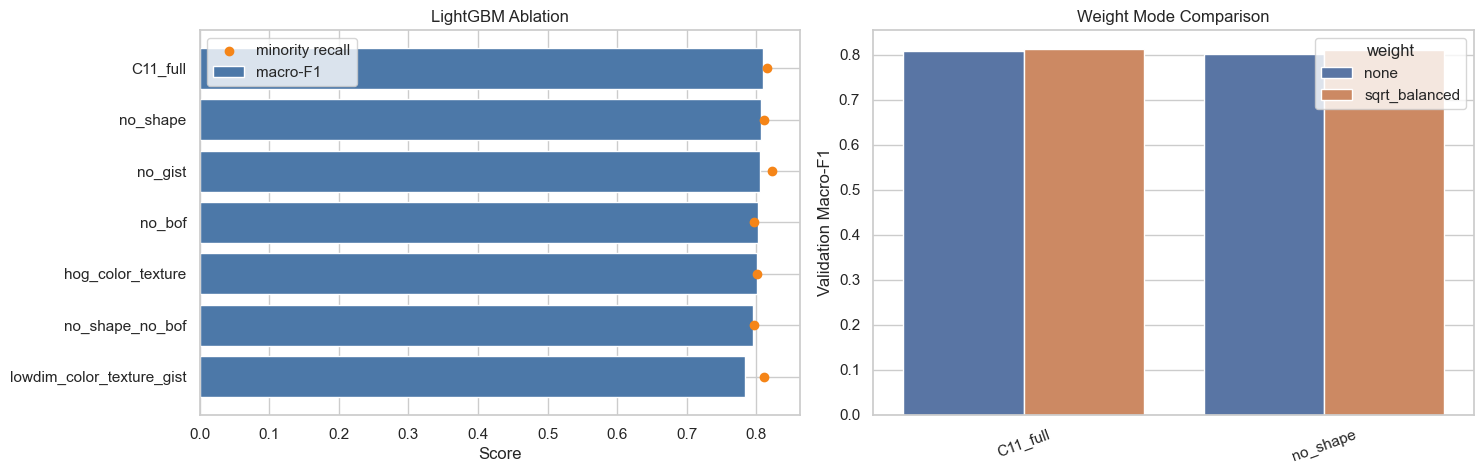


## 10. 阶段四（3）：Stacking 集成

当单个 LightGBM 的 validation macro-F1 达到 0.8131 后，继续调参的边际收益已经变小。因此，本阶段尝试 stacking 集成，通过学习不同模型输出之间的互补关系进一步提升性能。Stacking 的关键不是简单堆模型，而是构造具有差异性的 base learner，使它们在特征空间、模型假设和错误模式上尽量不同。

本项目设计了 6 个 base learner。`lr_c11_balanced` 使用 C11 全量手工特征和 Logistic Regression，validation macro-F1 = 0.6639，提供线性概率输出。`sgd_svm_hct_balanced` 使用 HOG+Color+Texture 和线性 SVM，validation macro-F1 = 0.6139，提供最大间隔方向的 decision 输出。`rf_lowdim_balanced` 使用 Color+Texture+GIST 低维组合和 Random Forest，validation macro-F1 = 0.7035，少数类 recall = 0.7635，对少数类有补充价值。`knn_compact_gist_texture_shape` 使用 GIST+Texture+Shape 106 维紧凑特征，validation macro-F1 = 0.5492，提供局部邻域视角。`lgbm_small_hct_sqrt` 使用 HOG+Color+Texture，validation macro-F1 = 0.7899，是紧凑强模型。`lgbm_anchor_c11_sqrt` 使用 C11 full，validation macro-F1 接近阶段四最强单模型，是 anchor。

Meta learner 采用 Logistic Regression，输入为 base learner 的 OOF 预测结果。训练时先在 train split 上做 5-fold OOF，避免 meta learner 直接学习 base learner 在训练样本上的过拟合输出；validation 集只用于比较 ensemble 方案。最终比较了 small-only stacking、small+anchor stacking、small probability average 和 probability average + anchor。结果显示，small-only stacking 的 validation macro-F1 = 0.7981，说明小模型互补性存在但不足以超过强单模型；简单概率平均 + anchor 的 macro-F1 = 0.8009，低于学习式 stacking；small + LGBM anchor stacking 的 validation macro-F1 = 0.8178，少数类 recall = 0.8151，相比阶段四最强单模型 0.8131 提升 0.0047。

因此，最终封存模型确定为 `stack_small_plus_lgbm_anchor`，在最终 train+validation 重训和 test 评价阶段命名为 **Garbage Net**。该命名指代由多个传统机器学习模型与 LightGBM anchor 组成的 stacking 集成框架。

Stacking 输出中的一个关键现象是，简单平均并没有充分利用 base learner。small probability average 的 validation macro-F1 = 0.7686，probability average + anchor 为 0.8009，均低于学习式 stacking。原因在于不同 base learner 的可靠性不同，简单平均会给弱模型过高权重；Logistic Regression meta learner 可以根据 OOF 预测自动学习各类别和各模型的相对可信度。因此，Garbage Net 的改进来自“有监督地融合预测”，而不是机械平均。

Stacking 的设计遵循“强 anchor + 异质补充”的原则。若只使用小模型，模型上限不足；若只使用强 LightGBM，则缺少其他学习偏好的补充。Garbage Net 同时保留 C11 anchor、紧凑 LightGBM、线性模型、森林模型和邻域模型，使 meta learner 能在类别层面学习不同 base learner 的可信度。


**Stacking base learners**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>base_id</th>
      <th>group</th>
      <th>model_type</th>
      <th>combo_id</th>
      <th>feature_dim_raw</th>
      <th>output_type</th>
      <th>validation_macro_f1</th>
      <th>validation_minority_recall_mean</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>lgbm_anchor_c11_sqrt</td>
      <td>anchor</td>
      <td>lightgbm</td>
      <td>C11_full</td>
      <td>3165</td>
      <td>proba</td>
      <td>0.8131</td>
      <td>0.8158</td>
    </tr>
    <tr>
      <th>1</th>
      <td>lgbm_small_hct_sqrt</td>
      <td>small</td>
      <td>lightgbm</td>
      <td>hog_color_texture</td>
      <td>2833</td>
      <td>proba</td>
      <td>0.7899</td>
      <td>0.7895</td>
    </tr>
    <tr>
      <th>2</th>
      <td>rf_lowdim_balanced</td>
      <td>small</td>
      <td>random_forest</td>
      <td>lowdim_color_texture_gist</td>
      <td>1133</td>
      <td>proba</td>
      <td>0.7035</td>
      <td>0.7635</td>
    </tr>
    <tr>
      <th>3</th>
      <td>lr_c11_balanced</td>
      <td>small</td>
      <td>logreg</td>
      <td>C11_full</td>
      <td>3165</td>
      <td>proba</td>
      <td>0.6639</td>
      <td>0.7037</td>
    </tr>
    <tr>
      <th>4</th>
      <td>sgd_svm_hct_balanced</td>
      <td>small</td>
      <td>sgd_svm</td>
      <td>hog_color_texture</td>
      <td>2833</td>
      <td>decision</td>
      <td>0.6139</td>
      <td>0.5780</td>
    </tr>
    <tr>
      <th>5</th>
      <td>knn_compact_gist_texture_shape</td>
      <td>small</td>
      <td>knn</td>
      <td>gist_texture_shape</td>
      <td>106</td>
      <td>proba</td>
      <td>0.5492</td>
      <td>0.5398</td>
    </tr>
  </tbody>
</table>
</div>

**Ensemble 方案对比**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>ensemble_id</th>
      <th>ensemble_type</th>
      <th>num_base_models</th>
      <th>num_meta_features</th>
      <th>meta_model</th>
      <th>meta_C</th>
      <th>meta_weight_mode</th>
      <th>validation_accuracy</th>
      <th>validation_macro_f1</th>
      <th>validation_minority_recall_mean</th>
      <th>delta_macro_f1_vs_stage4_best</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>stack_small_plus_lgbm_anchor</td>
      <td>stacking</td>
      <td>6</td>
      <td>60</td>
      <td>LogisticRegression</td>
      <td>0.1000</td>
      <td>none</td>
      <td>0.8211</td>
      <td>0.8178</td>
      <td>0.8151</td>
      <td>0.0047</td>
    </tr>
    <tr>
      <th>1</th>
      <td>avg_small_plus_lgbm_anchor_proba</td>
      <td>soft_average</td>
      <td>5</td>
      <td>50</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>0.8086</td>
      <td>0.8009</td>
      <td>0.7988</td>
      <td>-0.0123</td>
    </tr>
    <tr>
      <th>2</th>
      <td>stack_small_only</td>
      <td>stacking</td>
      <td>5</td>
      <td>50</td>
      <td>LogisticRegression</td>
      <td>0.1000</td>
      <td>sqrt_sample_weight</td>
      <td>0.8042</td>
      <td>0.7981</td>
      <td>0.8129</td>
      <td>-0.0151</td>
    </tr>
    <tr>
      <th>3</th>
      <td>avg_small_proba</td>
      <td>soft_average</td>
      <td>4</td>
      <td>40</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>NaN</td>
      <td>0.7787</td>
      <td>0.7686</td>
      <td>0.7817</td>
      <td>-0.0445</td>
    </tr>
  </tbody>
</table>
</div>

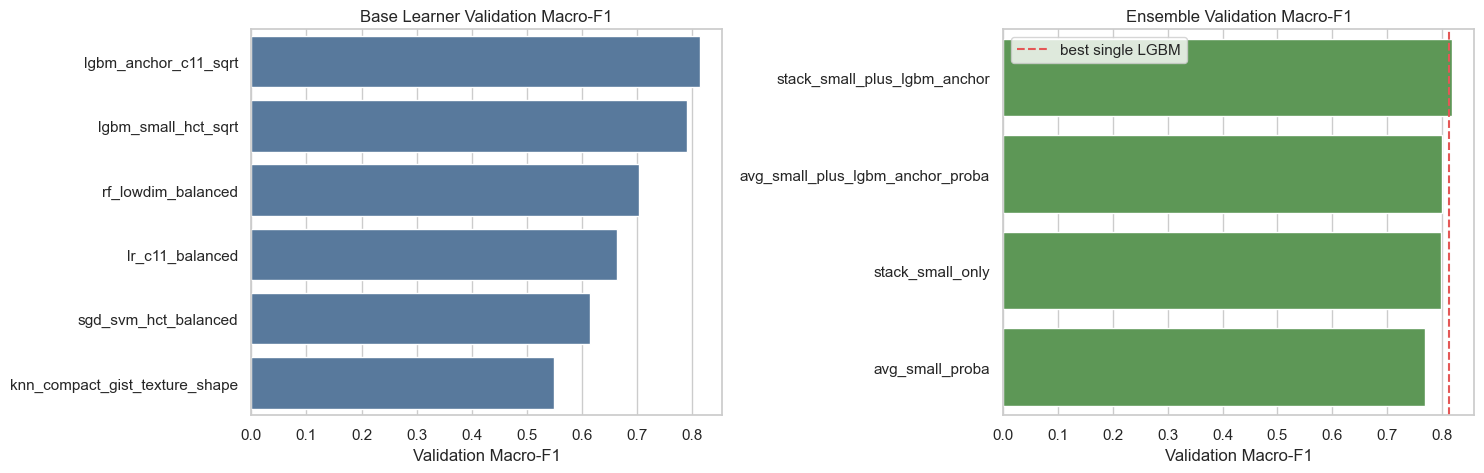

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Garbage Net validation macro-F1</th>
      <th>Garbage Net validation minority recall</th>
      <th>base models</th>
      <th>meta features</th>
      <th>meta learner</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>0.8178</td>
      <td>0.8151</td>
      <td>6</td>
      <td>60</td>
      <td>LogisticRegression</td>
    </tr>
  </tbody>
</table>
</div>


## 11. 最终 test 集评价

最终评价严格遵循“validation 选模、test 封存评价”的模式。模型结构、base learner 列表、meta learner 类型和参数均在 validation 阶段确定；test 集不参与任何特征选择、参数搜索或 ensemble 方案比较。最终训练时，train 与 validation 合并为 trainval，共 10420 张图像；在 trainval 上重新生成 5-fold OOF 预测训练 meta learner，然后各 base learner 使用完整 trainval 重训，最后对 1839 张 test 图像预测一次。

Garbage Net 在 test 集上取得 accuracy = 0.8238、macro precision = 0.8213、macro recall = 0.8029、macro-F1 = 0.8097、weighted-F1 = 0.8228，少数类 recall 均值 = 0.7420。与最终单模型 LGBM C11 anchor 相比，anchor 的 test macro-F1 = 0.7950、accuracy = 0.8097、少数类 recall = 0.7231；Garbage Net 在 macro-F1 上提升约 0.0147，在 accuracy 上提升约 0.0141，说明 stacking 的提升在 test 上仍然成立，而不是只出现在 validation 上。

各类别指标显示，clothes 表现最好，precision = 0.9085、recall = 0.9437、F1 = 0.9257；shoes 的 F1 = 0.8345，cardboard 的 F1 = 0.8401，glass 的 F1 = 0.8280，battery 的 F1 = 0.8230，biological 的 F1 = 0.8155，paper 的 F1 = 0.8139。相对较弱的类别包括 plastic、metal 和 trash，其中 plastic precision = 0.7686、recall = 0.7333、F1 = 0.7505；metal F1 = 0.7586；trash precision = 0.8542 但 recall 只有 0.6029，F1 = 0.7069。trash 的高 precision 和低 recall 表明模型在预测为 trash 时较谨慎，但漏掉了较多真实 trash 样本。

validation 到 test 的表现存在正常回落：validation stacking macro-F1 = 0.8178，test macro-F1 = 0.8097，下降约 0.0081。该差距在图像分类任务中属于可接受范围，说明模型没有明显过拟合 validation。最终图表包括模型对比、Garbage Net 混淆矩阵和逐类别 precision/recall/F1，能够从整体和类别两个层面展示模型效果。

最终 test 表还可以验证 ensemble 的实际收益。final small-only stacking 的 test macro-F1 = 0.8036，低于 Garbage Net 的 0.8097，但高于很多单个小模型，说明小模型组合已经有一定互补性；加入 LGBM anchor 后，模型同时获得强单模型的稳定性和小模型的补充信息。weighted-F1 = 0.8228 高于 macro-F1 = 0.8097，说明样本较多类别表现更好，而 macro-F1 更严格地反映了少数类和困难类的影响。

最终 test 输出中的混淆矩阵、per-class 指标和错误对表互相补充。总体指标说明模型强弱，per-class 指标说明哪些类别表现稳定，混淆矩阵显示错误分布，错误对表则直接指出最值得分析的类别对。四类输出合在一起，才能避免只用一个 macro-F1 概括所有问题。


**Garbage Net 最终 test 指标**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model_name</th>
      <th>model_id</th>
      <th>test_accuracy</th>
      <th>test_macro_f1</th>
      <th>test_weighted_f1</th>
      <th>test_minority_recall_mean</th>
      <th>test_recall_trash</th>
      <th>test_recall_battery</th>
      <th>test_recall_biological</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Garbage Net</td>
      <td>final_stack_small_plus_lgbm_anchor</td>
      <td>0.8238</td>
      <td>0.8097</td>
      <td>0.8228</td>
      <td>0.7420</td>
      <td>0.6029</td>
      <td>0.8230</td>
      <td>0.8000</td>
    </tr>
  </tbody>
</table>
</div>

**最终 ensemble 方案 test 对比**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model_id</th>
      <th>model_type</th>
      <th>num_base_models</th>
      <th>test_accuracy</th>
      <th>test_macro_f1</th>
      <th>test_weighted_f1</th>
      <th>test_minority_recall_mean</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>final_stack_small_plus_lgbm_anchor</td>
      <td>stacking</td>
      <td>6</td>
      <td>0.8238</td>
      <td>0.8097</td>
      <td>0.8228</td>
      <td>0.7420</td>
    </tr>
    <tr>
      <th>1</th>
      <td>final_stack_small_only</td>
      <td>stacking</td>
      <td>5</td>
      <td>0.8173</td>
      <td>0.8036</td>
      <td>0.8170</td>
      <td>0.7486</td>
    </tr>
    <tr>
      <th>2</th>
      <td>final_avg_small_plus_lgbm_anchor_proba</td>
      <td>soft_average</td>
      <td>5</td>
      <td>0.8173</td>
      <td>0.8029</td>
      <td>0.8159</td>
      <td>0.7444</td>
    </tr>
    <tr>
      <th>3</th>
      <td>final_avg_small_proba</td>
      <td>soft_average</td>
      <td>4</td>
      <td>0.7868</td>
      <td>0.7687</td>
      <td>0.7851</td>
      <td>0.7147</td>
    </tr>
  </tbody>
</table>
</div>

**Garbage Net 逐类别 test 指标**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>class_name</th>
      <th>support</th>
      <th>precision</th>
      <th>recall</th>
      <th>f1</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>battery</td>
      <td>113</td>
      <td>0.8230</td>
      <td>0.8230</td>
      <td>0.8230</td>
    </tr>
    <tr>
      <th>1</th>
      <td>biological</td>
      <td>105</td>
      <td>0.8317</td>
      <td>0.8000</td>
      <td>0.8155</td>
    </tr>
    <tr>
      <th>2</th>
      <td>cardboard</td>
      <td>212</td>
      <td>0.8502</td>
      <td>0.8302</td>
      <td>0.8401</td>
    </tr>
    <tr>
      <th>3</th>
      <td>clothes</td>
      <td>284</td>
      <td>0.9085</td>
      <td>0.9437</td>
      <td>0.9257</td>
    </tr>
    <tr>
      <th>4</th>
      <td>glass</td>
      <td>260</td>
      <td>0.8141</td>
      <td>0.8423</td>
      <td>0.8280</td>
    </tr>
    <tr>
      <th>5</th>
      <td>metal</td>
      <td>140</td>
      <td>0.7333</td>
      <td>0.7857</td>
      <td>0.7586</td>
    </tr>
    <tr>
      <th>6</th>
      <td>paper</td>
      <td>200</td>
      <td>0.8079</td>
      <td>0.8200</td>
      <td>0.8139</td>
    </tr>
    <tr>
      <th>7</th>
      <td>plastic</td>
      <td>240</td>
      <td>0.7686</td>
      <td>0.7333</td>
      <td>0.7505</td>
    </tr>
    <tr>
      <th>8</th>
      <td>shoes</td>
      <td>217</td>
      <td>0.8214</td>
      <td>0.8479</td>
      <td>0.8345</td>
    </tr>
    <tr>
      <th>9</th>
      <td>trash</td>
      <td>68</td>
      <td>0.8542</td>
      <td>0.6029</td>
      <td>0.7069</td>
    </tr>
  </tbody>
</table>
</div>

**主要错误对 Top 12**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>true_label</th>
      <th>predicted_label</th>
      <th>count</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>plastic</td>
      <td>glass</td>
      <td>24</td>
    </tr>
    <tr>
      <th>1</th>
      <td>glass</td>
      <td>plastic</td>
      <td>15</td>
    </tr>
    <tr>
      <th>2</th>
      <td>cardboard</td>
      <td>plastic</td>
      <td>13</td>
    </tr>
    <tr>
      <th>3</th>
      <td>glass</td>
      <td>shoes</td>
      <td>9</td>
    </tr>
    <tr>
      <th>4</th>
      <td>paper</td>
      <td>shoes</td>
      <td>9</td>
    </tr>
    <tr>
      <th>5</th>
      <td>plastic</td>
      <td>cardboard</td>
      <td>8</td>
    </tr>
    <tr>
      <th>6</th>
      <td>plastic</td>
      <td>paper</td>
      <td>8</td>
    </tr>
    <tr>
      <th>7</th>
      <td>plastic</td>
      <td>metal</td>
      <td>8</td>
    </tr>
    <tr>
      <th>8</th>
      <td>shoes</td>
      <td>clothes</td>
      <td>8</td>
    </tr>
    <tr>
      <th>9</th>
      <td>shoes</td>
      <td>paper</td>
      <td>8</td>
    </tr>
    <tr>
      <th>10</th>
      <td>trash</td>
      <td>metal</td>
      <td>8</td>
    </tr>
    <tr>
      <th>11</th>
      <td>paper</td>
      <td>clothes</td>
      <td>7</td>
    </tr>
  </tbody>
</table>
</div>

**最终评价图表**

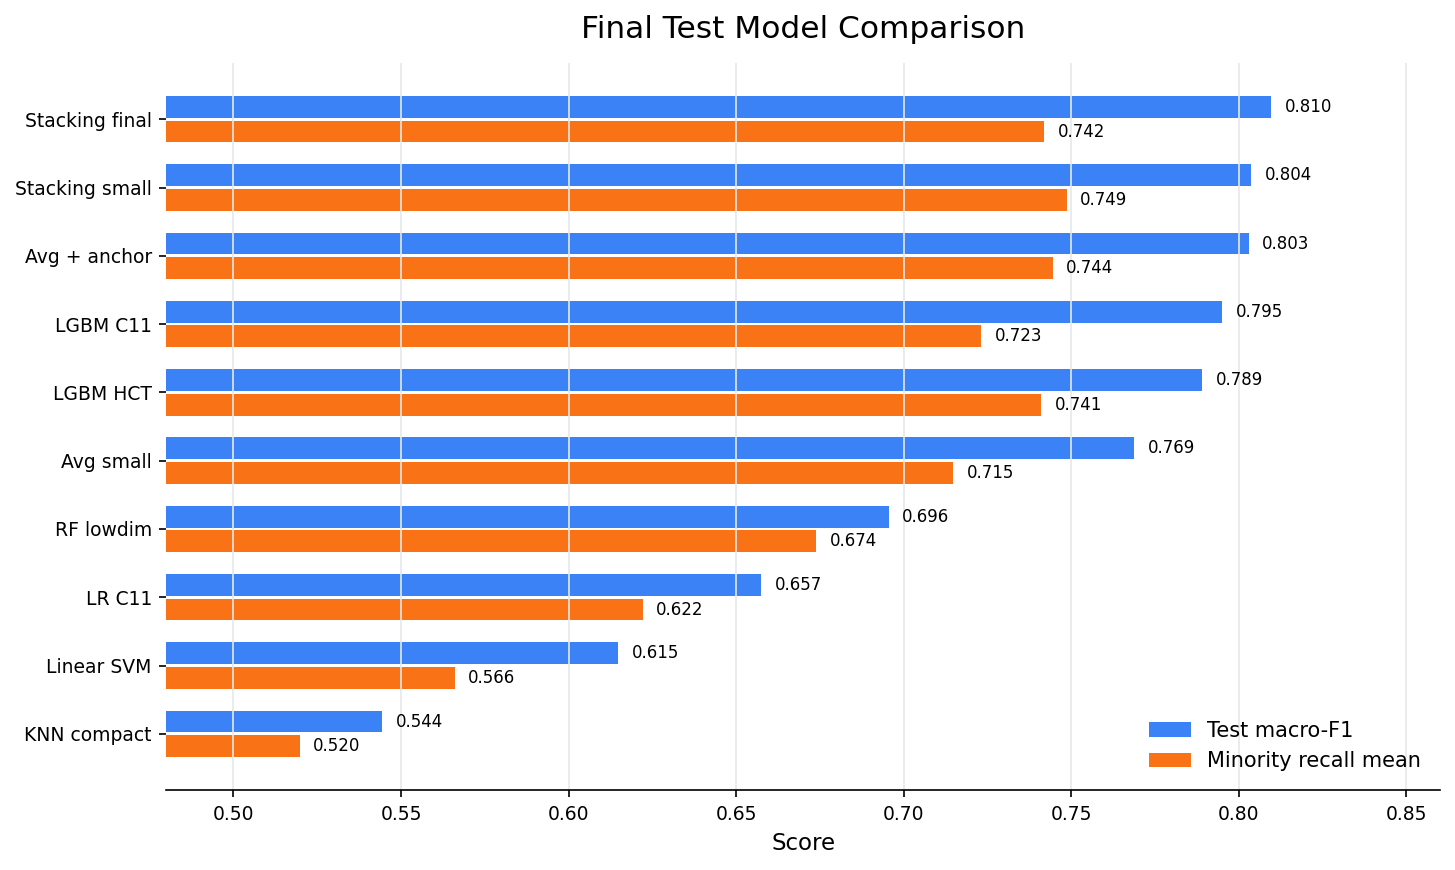

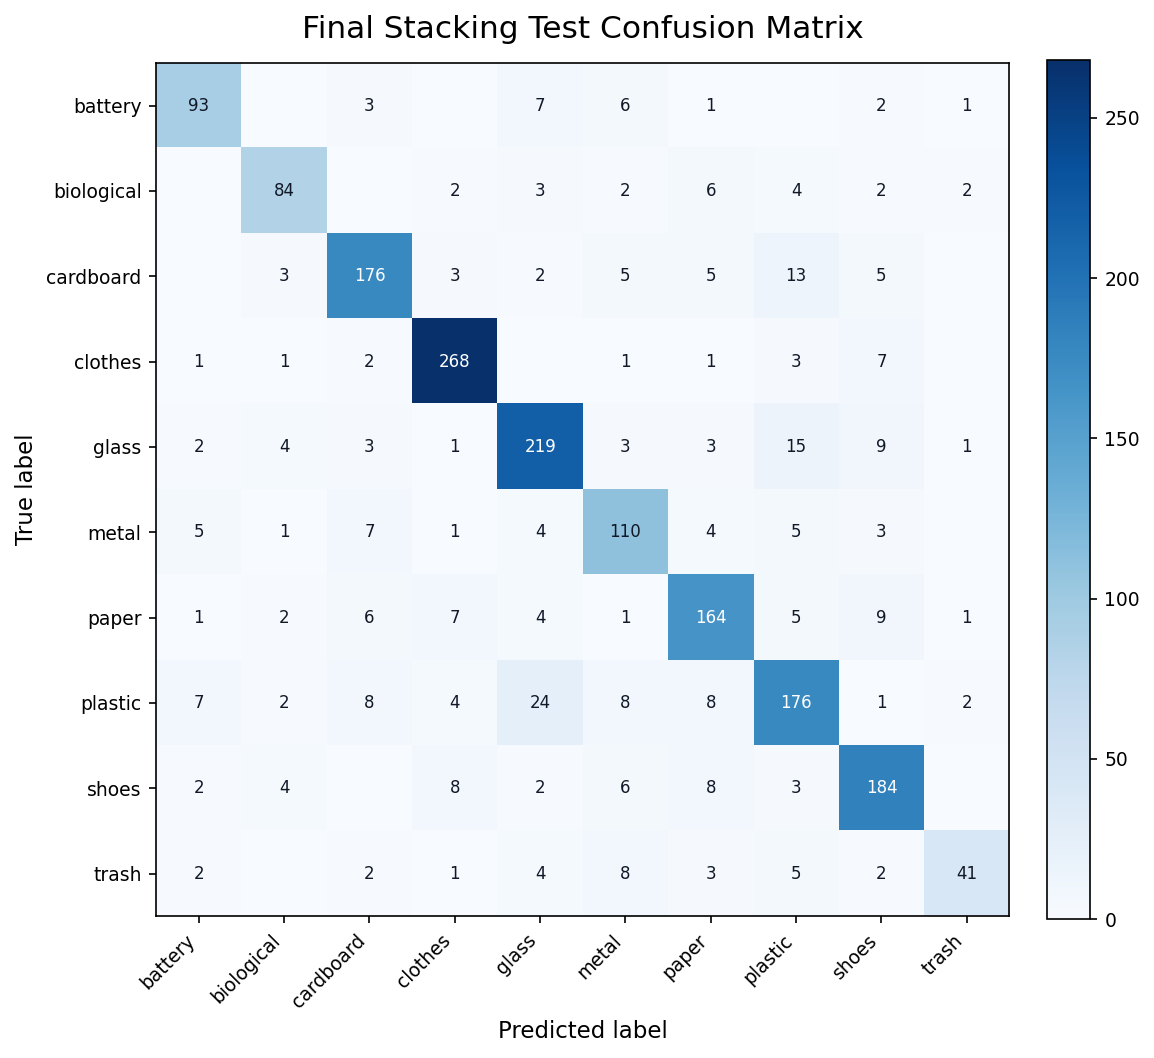

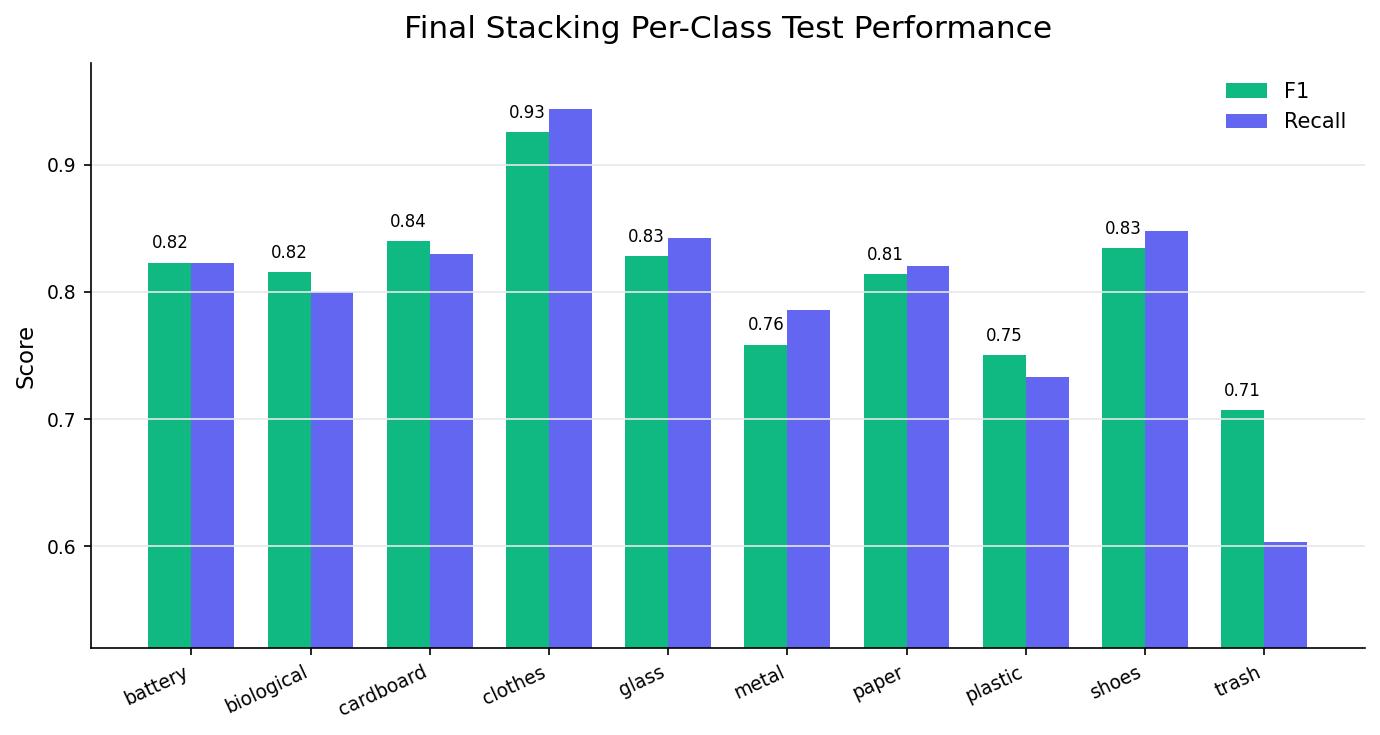


## 12. 错误分析

错误分析用于判断模型短板来自参数设置、特征表达还是数据本身的视觉歧义。最终错误对显示，最常见混淆是 plastic -> glass，共 24 次；glass -> plastic 共 15 次。这一对错误符合视觉直觉：塑料瓶、透明包装和玻璃瓶在颜色、透明度、边缘反光和局部纹理上较接近，手工颜色直方图和 HOG 边缘特征难以稳定区分材料本身。cardboard -> plastic 有 13 次，说明包装类图像中纸板与塑料外包装可能共享相似颜色和矩形轮廓。

其他高频错误包括 glass -> shoes、paper -> shoes、plastic -> cardboard、plastic -> paper、plastic -> metal、shoes -> clothes、shoes -> paper、trash -> metal 等。这些错误并不完全是模型“分类能力不足”，也与图像采集状态有关。例如 shoes 和 clothes 都可能包含布料纹理；paper 和 cardboard 都属于纤维材料，颜色与纹理相近；trash 类本身定义更宽泛，可能包含金属、塑料、纸张等多种外观，因此容易被模型划入更具体的材料类别。

从逐类别指标看，trash 是最终模型最主要短板。trash test recall = 0.6029，明显低于 battery 的 0.8230 和 biological 的 0.8000。其原因至少包括两点：第一，trash 样本只有 453 张，train 中仅 317 张，模型可学习的视觉模式较少；第二，trash 类语义更像“不能归入其他类别的杂项”，类内差异远大于 cardboard、paper、shoes 等相对稳定类别。对于这种类别，单纯继续调分类器参数的收益有限，更有效的方向可能是补充 trash 样本、进行类别内子类型标注、加入主体分割或使用深度特征增强语义表达。

误分类样本网格展示了模型高置信度错误。高置信度错误尤其值得关注，因为它说明模型不仅判断错误，而且对错误类别非常确信。这类样本可以作为后续数据清洗和特征改进的重点对象：若图像主体不清晰或标签本身存在争议，应考虑人工复核；若标签无误，则说明当前手工特征没有捕捉到区分该样本所需的信息。

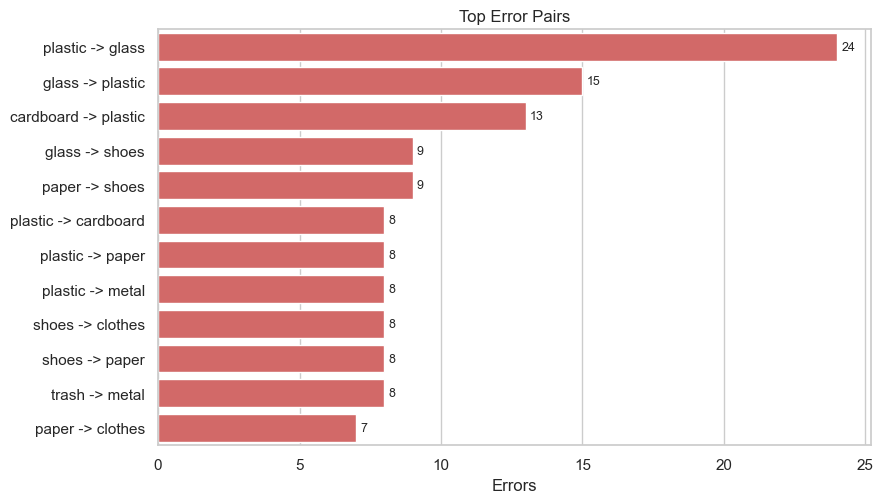

**高置信度误分类样本示例**

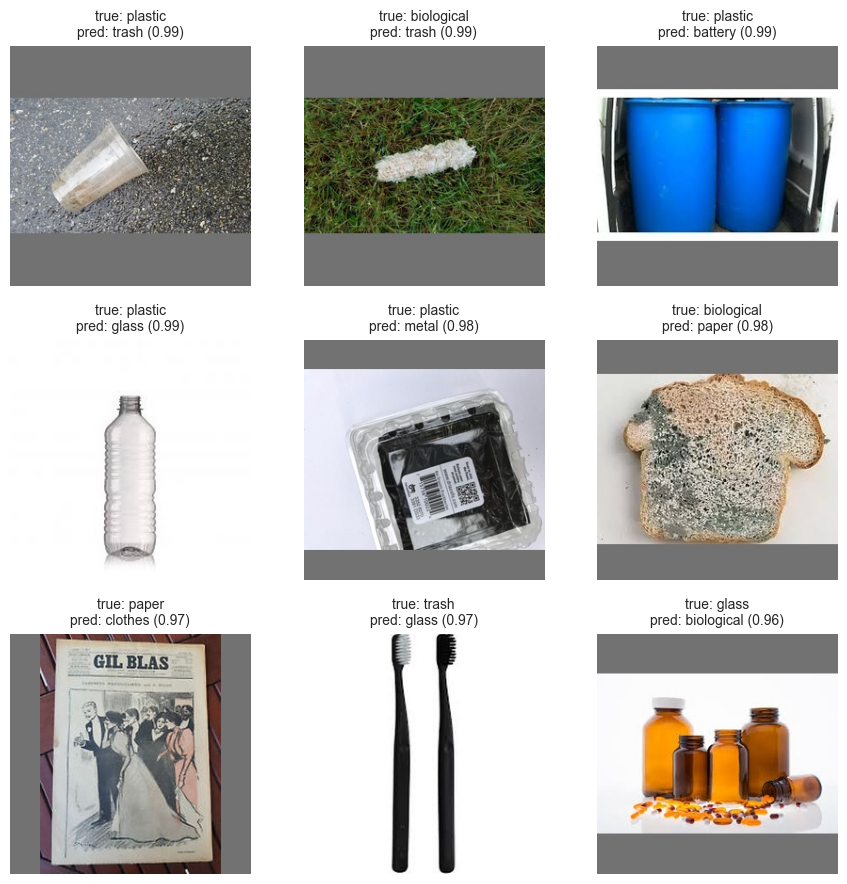


## 13. 与已有传统机器学习和神经网络结果的对比

本项目另外整理了若干传统机器学习文献方案的本地复刻结果，用作横向参照。复刻候选包括 Yang & Thung 2016 的 SIFT BoF + RBF SVM、Nguyen et al. 2026 的手工特征 + LightGBM/XGBoost、Mboli & Ogungbemi 2026 的 RGB/PCA + Random Forest/RBF SVM，以及 Sen et al. 2025 的 HOG+LBP 风格纹理 + Linear SVM。这些复刻只在 validation split 上评价，不参与核心模型选择，也不使用 test 集。

传统文献候选中，Nguyen 风格的 handcrafted LightGBM 表现最好，validation macro-F1 = 0.7653，少数类 recall = 0.7932；handcrafted XGBoost 的 macro-F1 = 0.7014，少数类 recall = 0.8056；RGB/PCA + RBF SVM 的 macro-F1 = 0.5550；RGB/PCA + Random Forest 的 macro-F1 = 0.5229；HOG+Texture Linear SVM 的 macro-F1 = 0.4846；Yang & Thung 风格 SIFT BoF + RBF SVM 的 macro-F1 = 0.4240。相比之下，Garbage Net validation macro-F1 = 0.8178，说明本项目的分阶段特征融合、类别权重和 stacking 设计相较直接复刻文献候选有明显提升。

与神经网络方法相比，Garbage Net 的定位不是替代高性能迁移学习或深度混合模型。已有研究表明，预训练 CNN、EfficientNet、DenseNet、ResNet 或深度特征 + 传统分类器在大规模图像分类中通常具有更高性能上限，尤其能够自动学习复杂语义特征。但深度模型也带来训练成本、可解释性、环境依赖和调参复杂度问题。本项目选择传统机器学习路线，是为了在可控计算成本下完整展示“图像 -> 手工特征 -> 特征融合 -> 模型筛选 -> 调参消融 -> 集成学习 -> 错误分析”的全过程。

因此，Garbage Net 更适合作为一个强传统机器学习基线。其价值在于：特征来源清楚，能够解释 HOG、Color、Texture、BoF 等特征的贡献；模型选择过程透明，能够说明 LightGBM 为什么成为主模型；类别不平衡处理有可比较结果，能够说明 `sqrt_balanced` 的作用；最终 stacking 的增益也能通过 validation 和 test 两个阶段验证。

文献对比部分的柱状图不是严格公平的排行榜。不同文献候选对应的特征维度、类别空间、参数完整性和本地映射方式并不完全相同，因此该表只说明本项目路线相较这些复刻候选更适合当前数据和实验目标。尤其是 Nguyen 风格 handcrafted LightGBM 已经达到 0.7653，说明“多手工特征 + boosting”方向本身有效；Garbage Net 的进一步提升来自更细的特征融合、权重选择和 stacking。

**传统文献候选的本地 validation 复刻结果**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>candidate_id</th>
      <th>source_short</th>
      <th>model_label</th>
      <th>feature_dim</th>
      <th>validation_accuracy</th>
      <th>validation_macro_f1</th>
      <th>validation_minority_recall_mean</th>
      <th>actual_train_seconds</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>nguyen_2026_handcrafted_lightgbm</td>
      <td>Nguyen et al. 2026</td>
      <td>LightGBM</td>
      <td>1401</td>
      <td>0.7656</td>
      <td>0.7653</td>
      <td>0.7932</td>
      <td>76.0078</td>
    </tr>
    <tr>
      <th>1</th>
      <td>nguyen_2026_handcrafted_xgboost</td>
      <td>Nguyen et al. 2026</td>
      <td>XGBoost</td>
      <td>1401</td>
      <td>0.7053</td>
      <td>0.7014</td>
      <td>0.8056</td>
      <td>43.7932</td>
    </tr>
    <tr>
      <th>2</th>
      <td>mboli_ogungbemi_2026_rgb_pca_rbf_svm</td>
      <td>Mboli &amp; Ogungbemi 2026</td>
      <td>PCA_RBF_SVM</td>
      <td>3072</td>
      <td>0.5650</td>
      <td>0.5550</td>
      <td>0.7133</td>
      <td>4.9598</td>
    </tr>
    <tr>
      <th>3</th>
      <td>mboli_ogungbemi_2026_rgb_pca_random_forest</td>
      <td>Mboli &amp; Ogungbemi 2026</td>
      <td>PCA_RandomForest</td>
      <td>3072</td>
      <td>0.5519</td>
      <td>0.5229</td>
      <td>0.4756</td>
      <td>4.5947</td>
    </tr>
    <tr>
      <th>4</th>
      <td>sen_2025_hog_lbp_linear_svm_reference</td>
      <td>Sen et al. 2025</td>
      <td>HOG_Texture_LinearSVM_SGD</td>
      <td>1794</td>
      <td>0.5063</td>
      <td>0.4846</td>
      <td>0.4658</td>
      <td>106.4668</td>
    </tr>
    <tr>
      <th>5</th>
      <td>yang_thung_2016_sift_bof_rbf_svm</td>
      <td>Yang &amp; Thung 2016</td>
      <td>RBF_SVM</td>
      <td>128</td>
      <td>0.4405</td>
      <td>0.4240</td>
      <td>0.4599</td>
      <td>8.5371</td>
    </tr>
  </tbody>
</table>
</div>

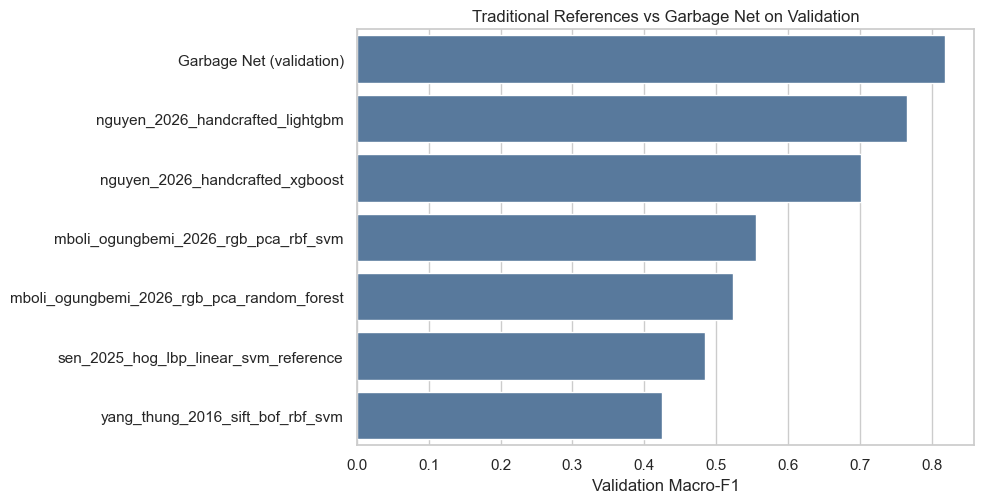


## 14. 总结与反思

本项目最终形成的 Garbage Net 是一个基于手工特征与传统机器学习的 stacking 集成模型。实验结果表明，传统方法在经过系统特征工程和模型组合后，可以在 10 类垃圾图像分类任务上取得较强表现。最终 test macro-F1 = 0.8097，accuracy = 0.8238，weighted-F1 = 0.8228，相比单模型 LightGBM anchor 的 test macro-F1 = 0.7950 有进一步提升。

从建模过程看，最关键的结论包括五点。第一，HOG 是最强单特征，调参后 HOG+KNN 的 validation macro-F1 达到 0.5612，是后续融合的自然起点。第二，Color 和 Texture 对少数类 recall 具有重要价值，Color+KNN 的少数类 recall 达到 0.5620，因此不能只根据单一 macro-F1 排名删除这些特征。第三，LightGBM 是最适合本项目高维混合手工特征的单模型，阶段三 C11 full + LightGBM 的 validation macro-F1 达到 0.8096，显著高于 Random Forest、Linear SVM、Logistic Regression、KNN 和 Decision Tree。第四，特征消融证明 BoF 在融合中具有真实贡献，去掉 BoF 后 macro-F1 从 0.8096 降至 0.8020，少数类 recall 也从 0.8158 降至 0.7961。第五，`sqrt_balanced` 是较合适的不平衡处理方式，使 C11 LightGBM validation macro-F1 提升到 0.8131。

Stacking 的作用也较明确。小模型本身并不一定强，例如 KNN compact 的 validation macro-F1 仅为 0.5492，Linear SVM 为 0.6139，但它们提供了与 LightGBM 不同的错误模式和输出视角。当这些模型与 LGBM anchor 一起进入 meta learner 后，validation macro-F1 提升到 0.8178，test macro-F1 也达到 0.8097。该结果说明，异质模型集成在传统特征体系中仍具有实际意义。

模型短板主要集中在 trash 类和 plastic/glass 等易混淆类别。后续改进可从三方面展开：一是补充 trash 等少数类样本，或进行更有针对性的数据增强；二是改进主体区域提取，减少背景对颜色和纹理统计的干扰；三是在保持传统模型可解释性的前提下，引入深度特征作为额外对照，进一步比较手工特征、深度特征和混合特征的边界。

总体来看，本项目的结果支持两个判断。第一，传统机器学习并非只能作为低性能 baseline；在特征工程充分、模型筛选系统、类别不平衡处理合理的情况下，传统方法仍能形成较强分类器。第二，传统方法的上限高度依赖特征表达，如果输入特征没有捕捉到材料语义或主体区域，后续模型很难弥补。因此，Garbage Net 的意义在于给出了一条结构清晰、结果可复查的传统建模路线，同时也明确指出了未来引入更强视觉表征的必要性。


## 致谢
谢谢薛老师的这学期的授课！